# Análisis Topológico de Datos: Homología Persistente

### Objetivo
Aplicar **homología persistente** (H0 y H1) sobre el espacio de ingesta de ácido fólico para:
- Detectar **componentes conexas** (H0) y **ciclos** (H1) en el espacio multidimensional de ingesta.
- Comparar la topología entre subgrupos de suplementación.
- Relacionar estructura topológica con riesgo perinatal (prematuridad, bajo peso al nacer).
- Validar subgrupos identificados con pruebas estadísticas y clasificación supervisada.

### Variables del espacio TDA
| Variable | Descripción |
|---|---|
| `uf_af` | Dosis de AF por suplemento (µg/día) |
| `n_panes_num` | N° de panes consumidos por día |
| `NO consumio` | Sin suplemento (binaria) |
| `Antes del embarazo` / `Durante todo el embarazo` | Timing de suplementación (binarias) |
| `Marraqueta` / `Hallulla` / `Pan molde integral` | Tipo de pan consumido (binarias) |

### Variables de resultado *(no entran al espacio TDA)*
| Variable | Descripción |
|---|---|
| `eg_num` | Edad gestacional al parto (semanas) |
| `pnacer_num` | Peso del recién nacido (g) |
| `prematuro` / `bajo_peso_rn` / `resultado_adverso` | Etiquetas de desenlace perinatal |

## Instalación de dependencias

`ripser` y `persim` no forman parte de la distribución estándar de SciPy/scikit-learn.
Se instalan en tiempo de ejecución solo si no están disponibles en el entorno.

In [59]:
import subprocess
import sys

for pkg in ['ripser', 'persim']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])


## Librerías y configuración global

Paleta de colores (`PALETTE`) y ajustes de matplotlib compartidos en todas las visualizaciones del notebook.

In [60]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, chi2_contingency
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from matplotlib.lines import Line2D
import ripser
import persim
import warnings
warnings.filterwarnings('ignore')

# Estilo base: fondo blanco limpio, sin bordes decorativos
sns.set_style('white')
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
    'axes.titlesize'    : 13,        # jerarquía: título > etiquetas > ticks
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'axes.spines.top'   : False,     # elimina bordes superfluo
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#E0E0E0', # grid sutil, gris muy claro
    'grid.linestyle'    : ':',
    'grid.linewidth'    : 0.6,
    'grid.alpha'        : 0.7,
    'legend.frameon'    : False,     # leyendas sin caja
    'figure.dpi'        : 130,
    'savefig.dpi'       : 300,       # alta resolución al guardar
    'savefig.bbox'      : 'tight',
})

# Paleta accesible para daltonismo (deuteranopía): azul/rojo diferenciables
PALETTE = {
    'primary'  : '#2166AC',   # azul corporativo
    'secondary': '#D6604D',   # rojo-salmón (safe vs azul en deuteranopía)
    'accent'   : '#F4A582',   # naranja suave
    'green'    : '#4DAC26',   # verde medio
    'light'    : '#92C5DE',   # azul claro
    'gray'     : '#636363',   # gris neutro
    'purple'   : '#762A83',   # púrpura
}


## Carga del dataset

Resolución de path por búsqueda en candidatos: directorio actual y directorio padre.
Permite ejecutar el notebook desde `Mapper/` o desde la raíz del proyecto sin modificar la ruta manualmente.

In [61]:
from pathlib import Path

base = Path.cwd()
candidates = [
    base / 'Data' / 'Ingesta_AF_clean.csv',
    base.parent / 'Data' / 'Ingesta_AF_clean.csv',
    base / 'data' / 'Ingesta_AF_clean.csv',
    base.parent / 'data' / 'Ingesta_AF_clean.csv',
]
data_path = None
for p in candidates:
    if p.exists():
        data_path = p
        break
if data_path is None:
    raise FileNotFoundError(
        f'Ingesta_AF_clean.csv no encontrado en rutas esperadas: {candidates}'
    )

df = pd.read_csv(data_path)

print(f'Registros : {df.shape[0]:,}')
print(f'Variables : {df.shape[1]}')
print()
df.head(3)


Registros : 1,170
Variables : 73



,Cod,edad,region_chile,neduc,paridad,fnacimiento,Sexo,pnacer,Edad_gestacion ultimo hijo,sitgest,...,pnacer_raw,eg_raw,uf_af,n_panes,pnacer_num,eg_num,n_panes_num,prematuro,eg_cat,uso_supl
0,1,26.0,1,4,1,2015-01-15 00:00:00,2,3040,39,9,...,3040.0,39.0,1000.0,2.0,3040.0,39.0,2.0,0.0,39–40 (normal),Usó suplemento
1,2,36.0,1,6,2,2012-03-29 00:00:00,2,3875,39,5,...,3875.0,39.0,1000.0,3.0,3875.0,39.0,3.0,0.0,39–40 (normal),Usó suplemento
2,3,22.0,1,5,1,2011-11-22 00:00:00,1,2665,38,0,...,2665.0,38.0,NaN,2.0,2665.0,38.0,2.0,0.0,37–38 (temprano),No usó suplemento


In [62]:
df['bajo_peso_rn']      = (df['pnacer_num'] < 2500).astype(float)
df.loc[df['pnacer_num'].isna(), 'bajo_peso_rn'] = np.nan

df['resultado_adverso'] = ((df['prematuro'] == 1) | (df['bajo_peso_rn'] == 1)).astype(float)

# uf_af en µg/día: sin supl = NO consumio=1, baja = <1000 µg, adecuada = ≥1000 µg
df['cat_supl'] = 'Sin suplemento'
df.loc[(df['NO consumio'] == 0) & (df['uf_af'] <  1000), 'cat_supl'] = 'Dosis baja (<1000 µg/d)'
df.loc[(df['NO consumio'] == 0) & (df['uf_af'] >= 1000), 'cat_supl'] = 'Dosis adecuada (≥1000 µg/d)'

print('Resumen de variables clave:')
print(f'  uf_af disponible    : {df["uf_af"].notna().sum():,}  '
      f'(media={df["uf_af"].mean():.0f} µg/d)')
print(f'  n_panes_num disp.   : {df["n_panes_num"].notna().sum():,}  '
      f'(media={df["n_panes_num"].mean():.1f} panes/d)')
print(f'  eg_num disponible   : {df["eg_num"].notna().sum():,}  '
      f'(media={df["eg_num"].mean():.1f} sem)')
print(f'  pnacer_num disp.    : {df["pnacer_num"].notna().sum():,}  '
      f'(media={df["pnacer_num"].mean():.0f} g)')
print()
print(f'Resultados neonatales (etiquetas):')
print(f'  Prematuros (<37 sem)    : {df["prematuro"].sum():.0f} / {df["prematuro"].notna().sum()}  '
      f'({df["prematuro"].mean()*100:.1f}%)')
print(f'  Bajo peso RN (<2500 g)  : {df["bajo_peso_rn"].sum():.0f} / {df["bajo_peso_rn"].notna().sum()}  '
      f'({df["bajo_peso_rn"].mean()*100:.1f}%)')
print(f'  Resultado adverso       : {df["resultado_adverso"].sum():.0f}  '
      f'({df["resultado_adverso"].mean()*100:.1f}%)')
print()
print('Categorías de suplementación:')
print(df['cat_supl'].value_counts().to_string())


Resumen de variables clave:
  uf_af disponible    : 647  (media=2729 µg/d)
  n_panes_num disp.   : 1,159  (media=2.1 panes/d)
  eg_num disponible   : 1,065  (media=38.5 sem)
  pnacer_num disp.    : 1,058  (media=3348 g)

Resultados neonatales (etiquetas):
  Prematuros (<37 sem)    : 94 / 1065  (8.8%)
  Bajo peso RN (<2500 g)  : 55 / 1058  (5.2%)
  Resultado adverso       : 115  (9.8%)

Categorías de suplementación:
cat_supl
Dosis adecuada (≥1000 µg/d)    610
Sin suplemento                 525
Dosis baja (<1000 µg/d)         35


## Construcción del espacio TDA

Se define el subconjunto de variables de ingesta (`TDA_INTAKE`) que forman el espacio métrico.
Las variables de resultado (`OUTCOMES`) se usan exclusivamente como etiquetas de validación — no participan en la geometría del espacio.

- `uf_af` y `n_panes_num` son los ejes cuantitativos principales.
- Las binarias (tipo de pan, timing) añaden estructura categórica al espacio.
- NaN en binarias se imputan con 0 (ausencia de consumo).
- `RobustScaler` normaliza para mitigar el efecto de outliers en dosis de AF.
- La proyección PCA 2D sirve solo para visualización; la homología opera sobre el espacio de 8 dimensiones normalizado.

In [63]:
TDA_INTAKE = [
    'uf_af', 'n_panes_num',
    'NO consumio', 'Antes del embarazo', 'Durante todo el embarazo',
    'Marraqueta', 'Hallulla', 'Pan molde integral'
]
OUTCOMES = ['eg_num', 'pnacer_num', 'prematuro', 'bajo_peso_rn', 'resultado_adverso']

# uf_af y n_panes_num deben estar completos; binarias → 0 si NaN
df_tda = df[TDA_INTAKE + OUTCOMES + ['cat_supl']].dropna(subset=['uf_af', 'n_panes_num']).copy()
for col in ['NO consumio', 'Antes del embarazo', 'Durante todo el embarazo',
            'Marraqueta', 'Hallulla', 'Pan molde integral']:
    df_tda[col] = df_tda[col].fillna(0)
df_tda = df_tda.reset_index(drop=True)

print(f'Registros en espacio TDA : {len(df_tda):,}')
print(f'  Con resultado adverso  : {df_tda["resultado_adverso"].notna().sum()}')
print(f'  Resultado adverso = 1  : {df_tda["resultado_adverso"].sum():.0f}  '
      f'({df_tda["resultado_adverso"].mean()*100:.1f}%)')
print()

scaler             = RobustScaler()
X_scaled           = scaler.fit_transform(df_tda[TDA_INTAKE].values)

pca                = PCA(n_components=2, random_state=42)
X_pca              = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print(f'Varianza explicada PCA — PC1: {explained_variance[0]*100:.1f}%  '
      f'PC2: {explained_variance[1]*100:.1f}%  '
      f'Total: {explained_variance.sum()*100:.1f}%')


Registros en espacio TDA : 642
  Con resultado adverso  : 642
  Resultado adverso = 1  : 60  (9.3%)

Varianza explicada PCA — PC1: 47.0%  PC2: 15.0%  Total: 61.9%


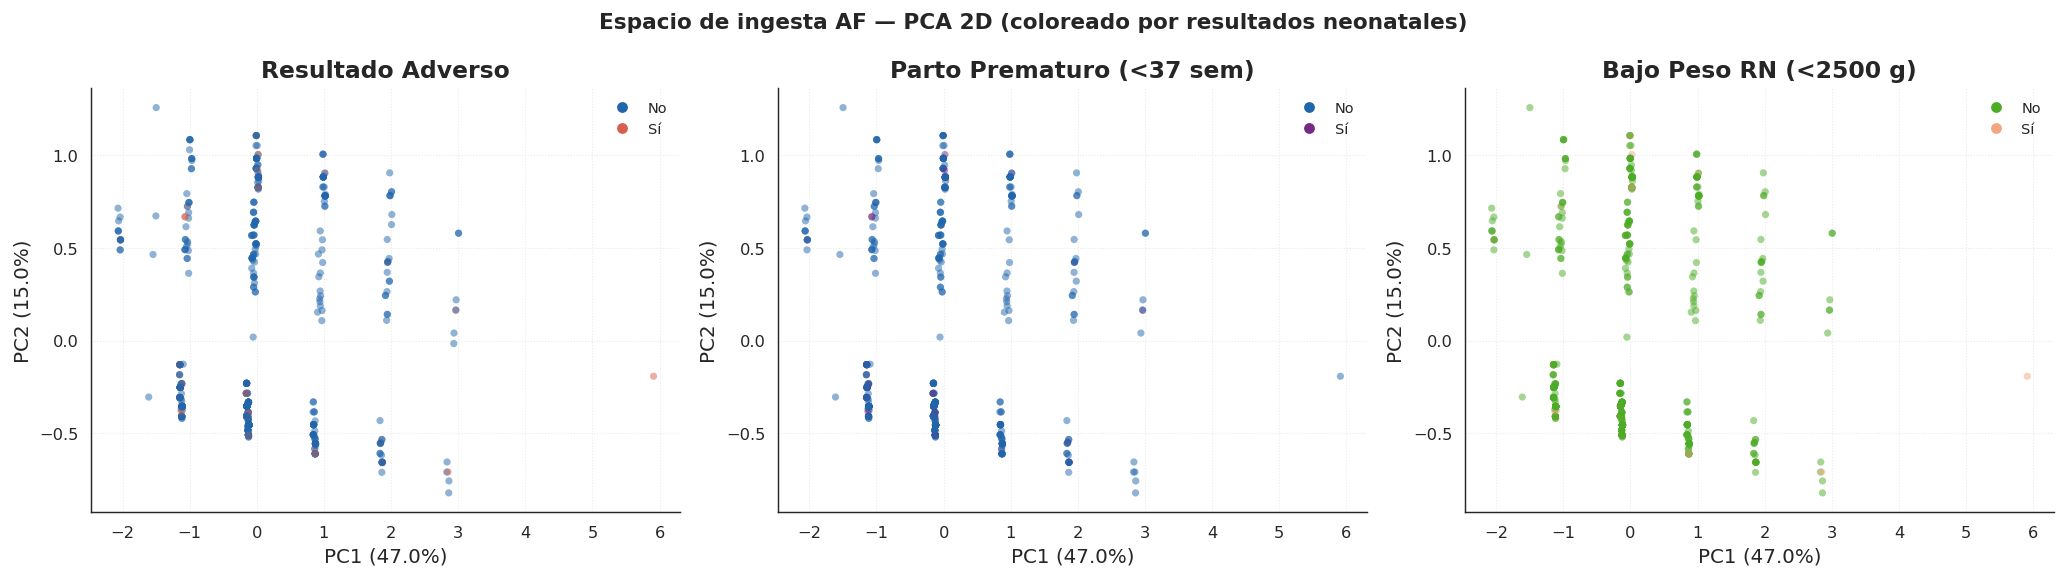

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))  # ligeramente más alto
fig.suptitle('Espacio de ingesta AF — PCA 2D (coloreado por resultados neonatales)',
             fontweight='bold')

for ax, col, title, c0, c1 in [
    (axes[0], 'resultado_adverso', 'Resultado Adverso',
     PALETTE['primary'], PALETTE['secondary']),
    (axes[1], 'prematuro',         'Parto Prematuro (<37 sem)',
     PALETTE['primary'], PALETTE['purple']),
    (axes[2], 'bajo_peso_rn',      'Bajo Peso RN (<2500 g)',
     PALETTE['green'],   PALETTE['accent']),
]:
    mask_v = df_tda[col].notna()
    colors = df_tda.loc[mask_v, col].map({0: c0, 1: c1})
    ax.scatter(X_pca[mask_v, 0], X_pca[mask_v, 1], c=colors,
               alpha=0.5, s=16, linewidths=0)  # sin borde en puntos
    ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor=c0, markersize=7, label='No'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=c1, markersize=7, label='Sí')],
        fontsize=8)  # frameon=False heredado del rcParams global

plt.tight_layout()
plt.show()


## Homología persistente

Complejo de **Vietoris-Rips** sobre el espacio de ingesta normalizado (8D).

- **H0** — componentes conexas: grupos de mujeres con patrones de ingesta similares que se conectan al mismo radio `ε`.
- **H1** — ciclos: relaciones no lineales entre fuentes de AF (suplemento vs. pan, dosis vs. timing).

Puntos alejados de la diagonal corresponden a características topológicas reales; los cercanos a la diagonal son ruido topológico.

In [65]:
def plot_barcode(
    ax: 'plt.Axes',
    dgm: 'np.ndarray',
    color: str,
    title: str,
    n_bars: int = 20,
) -> None:
    dgm_finite   = dgm[np.isfinite(dgm[:, 1])]
    dgm_infinite = dgm[~np.isfinite(dgm[:, 1])]
    if len(dgm_finite) > 0:
        persistence = dgm_finite[:, 1] - dgm_finite[:, 0]
        sort_idx    = np.argsort(persistence)[::-1]
        for i, j in enumerate(sort_idx[:n_bars]):
            ax.barh(i, persistence[j], left=dgm_finite[j, 0],
                    height=0.65, color=color, alpha=0.75)
    if len(dgm_infinite) > 0:
        x_max = dgm_finite[:, 1].max() if len(dgm_finite) > 0 else 1.0
        for k in range(len(dgm_infinite)):
            ax.barh(n_bars + k, x_max * 0.4, left=dgm_infinite[k, 0],
                    height=0.65, color=PALETTE['accent'], alpha=0.9)
    ax.set_xlabel('Radio ε')
    ax.set_title(title)
    ax.set_yticks([])                                    # índices de barra no aportan
    ax.spines['left'].set_visible(False)                 # spine izquierdo eliminado
    ax.grid(axis='x', linestyle=':', linewidth=0.6, alpha=0.5)  # grid sólo en x

print(f'Calculando homología persistente sobre {len(df_tda)} puntos en {len(TDA_INTAKE)}D…')
result_full = ripser.ripser(X_scaled, maxdim=1)
dgms_full   = result_full['dgms']
print(f'H0 — componentes conexas : {len(dgms_full[0])} características')
print(f'H1 — ciclos/bucles       : {len(dgms_full[1])} características')


Calculando homología persistente sobre 642 puntos en 8D…
H0 — componentes conexas : 184 características
H1 — ciclos/bucles       : 209 características


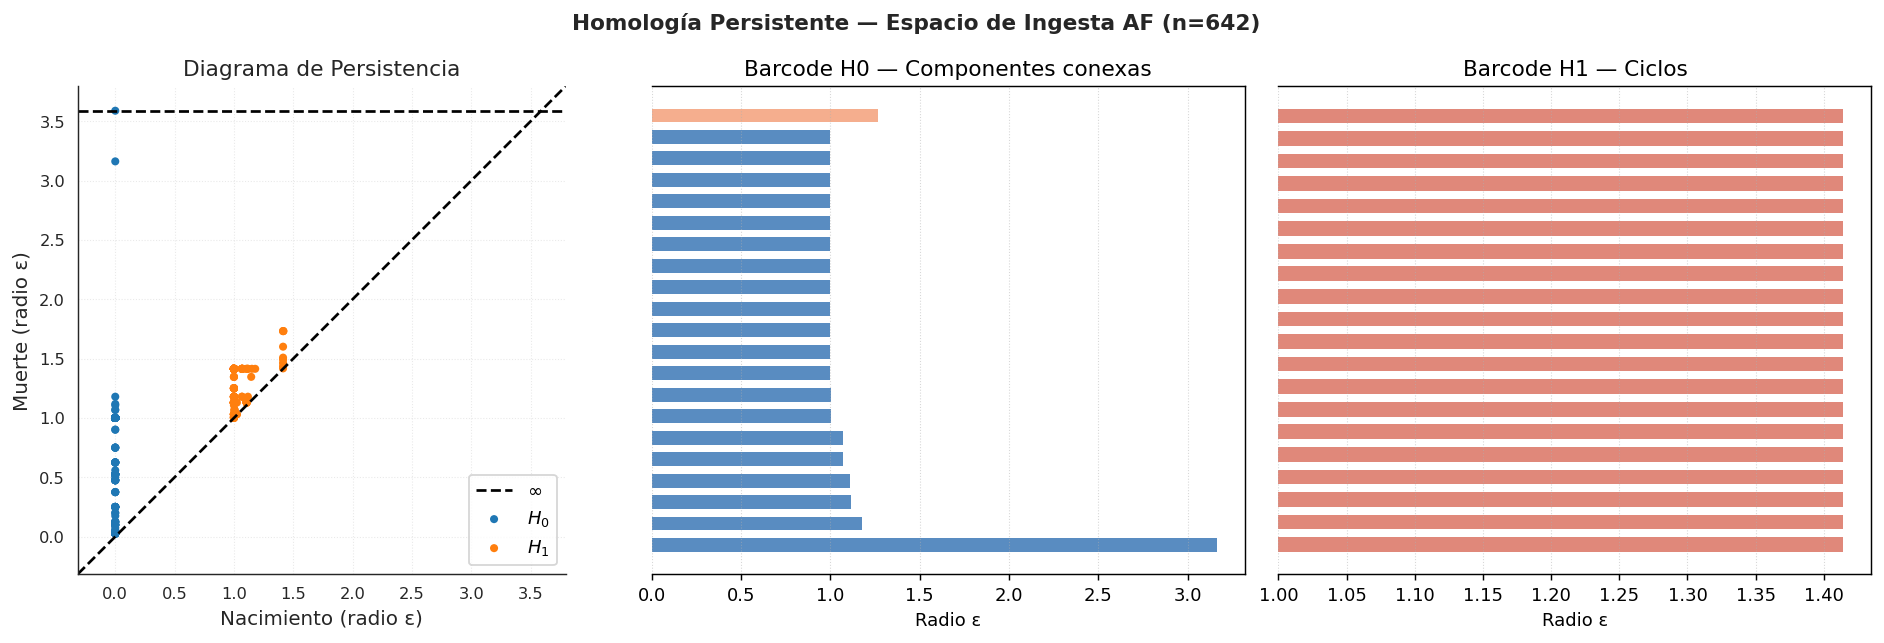

Top 6 H0:
 nacimiento  muerte  persistencia
        0.0  3.1624        3.1624
        0.0  1.1792        1.1792
        0.0  1.1180        1.1180
        0.0  1.1071        1.1071
        0.0  1.0680        1.0680
        0.0  1.0680        1.0680

Top 6 H1:
 nacimiento  muerte  persistencia
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142
        1.0  1.4142        0.4142



In [66]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle(f'Homología Persistente — Espacio de Ingesta AF (n={len(df_tda)})',
             fontweight='bold')

ax0 = fig.add_subplot(gs[0])
persim.plot_diagrams(dgms_full, ax=ax0, show=False)
ax0.set_title('Diagrama de Persistencia')
ax0.set_xlabel('Nacimiento (radio ε)')
ax0.set_ylabel('Muerte (radio ε)')
for sp in ['top', 'right']:  # persim no respeta rcParams de spines
    ax0.spines[sp].set_visible(False)

plot_barcode(fig.add_subplot(gs[1]), dgms_full[0], PALETTE['primary'],
             'Barcode H0 — Componentes conexas')
plot_barcode(fig.add_subplot(gs[2]), dgms_full[1], PALETTE['secondary'],
             'Barcode H1 — Ciclos')

plt.tight_layout()
plt.show()

for dim, dgm, label in [(0, dgms_full[0], 'H0'), (1, dgms_full[1], 'H1')]:
    dgm_finite  = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm_finite) == 0:
        continue
    persistence  = dgm_finite[:, 1] - dgm_finite[:, 0]
    sort_idx     = np.argsort(persistence)[::-1]
    top_features = pd.DataFrame({
        'nacimiento'  : dgm_finite[sort_idx[:6], 0],
        'muerte'      : dgm_finite[sort_idx[:6], 1],
        'persistencia': persistence[sort_idx[:6]],
    }).round(4)
    print(f'Top 6 {label}:')
    print(top_features.to_string(index=False))
    print()


## Comparación topológica por patrón de suplementación

El espacio TDA se segmenta en tres subgrupos según dosis de `uf_af`:
- **Sin suplemento** (`NO consumio == 1`)
- **Dosis baja** (`uf_af < 1000 µg/d`)
- **Dosis adecuada** (`uf_af ≥ 1000 µg/d`)

Para cada subgrupo se calcula homología independiente y se comparan las topologías mediante **distancia de Wasserstein** H1.

In [67]:
mask_sin  = df_tda['NO consumio'] == 1
mask_baja = (df_tda['NO consumio'] == 0) & (df_tda['uf_af'] <  1000)
mask_adec = (df_tda['NO consumio'] == 0) & (df_tda['uf_af'] >= 1000)

subgrupos = {
    'Sin suplemento'         : (mask_sin,  PALETTE['secondary']),
    'Dosis baja (<1000 µg/d)': (mask_baja, PALETTE['accent']),
    'Dosis adecuada (≥1000)' : (mask_adec, PALETTE['green']),
}

print(f'  {"Subgrupo":<28}  {"n":>4}  {"EG media":>9}  {"Peso RN":>9}  {"% adverso":>10}')
print('  ' + '-'*65)
for nombre, (mask, _) in subgrupos.items():
    n  = mask.sum()
    eg = df_tda.loc[mask, 'eg_num'].mean()
    pn = df_tda.loc[mask, 'pnacer_num'].mean()
    ra = df_tda.loc[mask, 'resultado_adverso'].mean()
    print(f'  {nombre:<28}  {n:>4}  {eg:>9.2f}  {pn:>9.0f}  {ra*100:>9.1f}%')

# Homología por subgrupo
dgms_sub = {}
for nombre, (mask, _) in subgrupos.items():
    if mask.sum() >= 15:
        print(f'\nCalculando TDA — {nombre} (n={mask.sum()})…')
        dgms_sub[nombre] = ripser.ripser(X_scaled[mask.values], maxdim=1)['dgms']

  Subgrupo                         n   EG media    Peso RN   % adverso
  -----------------------------------------------------------------
  Sin suplemento                   2      38.00       3575        0.0%
  Dosis baja (<1000 µg/d)         35      38.35       3224       11.4%
  Dosis adecuada (≥1000)         605      38.50       3352        9.3%

Calculando TDA — Dosis baja (<1000 µg/d) (n=35)…

Calculando TDA — Dosis adecuada (≥1000) (n=605)…


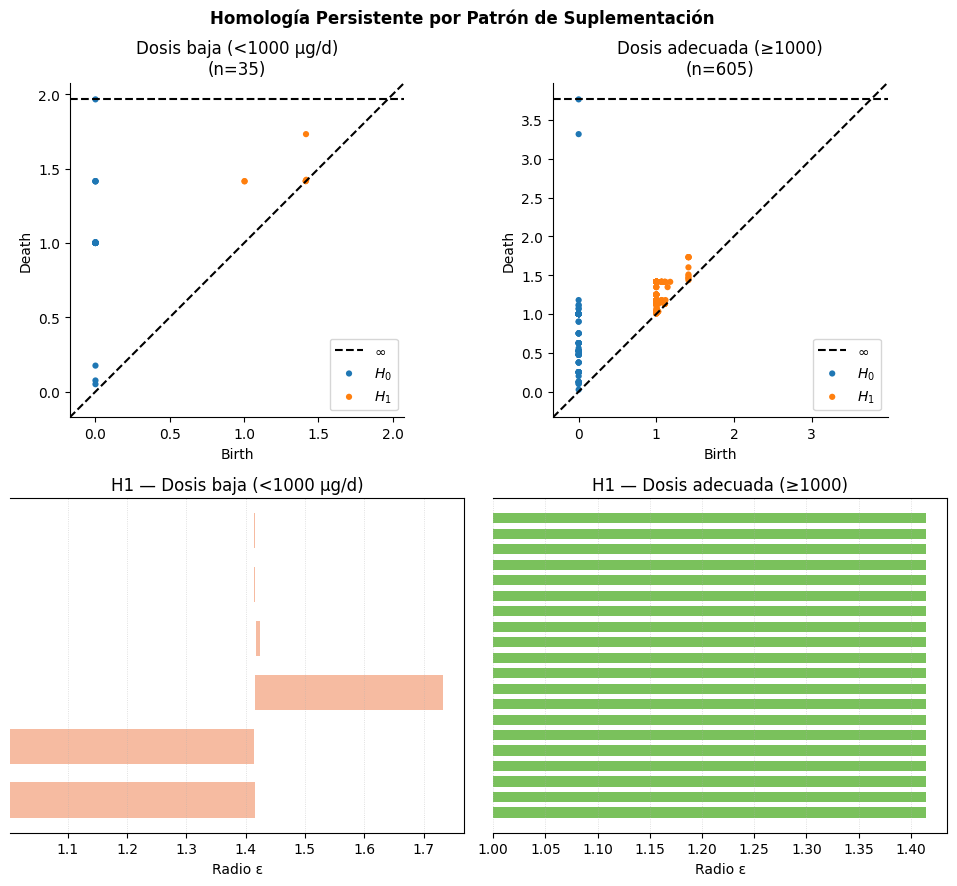

Distancias Wasserstein H1 entre subgrupos:
  Dosis baja (<1000 µg/d)      vs Dosis adecuada (≥1000)      : W = 33.1408

→ Mayor distancia Wasserstein = topologías más distintas entre subgrupos.


In [68]:
nombres = list(dgms_sub.keys())
fig, axes = plt.subplots(2, len(nombres), figsize=(5 * len(nombres), 9))
fig.suptitle('Homología Persistente por Patrón de Suplementación', fontweight='bold')

for col, nombre in enumerate(nombres):
    color = subgrupos[nombre][1]
    mask  = subgrupos[nombre][0]
    persim.plot_diagrams(dgms_sub[nombre], ax=axes[0, col], show=False)
    axes[0, col].set_title(f'{nombre}\n(n={mask.sum()})')
    for sp in ['top', 'right']:  # persim ignora rcParams
        axes[0, col].spines[sp].set_visible(False)
    plot_barcode(axes[1, col], dgms_sub[nombre][1], color, f'H1 — {nombre}')

plt.tight_layout()
plt.show()

from persim import wasserstein
print('Distancias Wasserstein H1 entre subgrupos:')
for i in range(len(nombres)):
    for j in range(i + 1, len(nombres)):
        a, b = nombres[i], nombres[j]
        if len(dgms_sub[a][1]) > 0 and len(dgms_sub[b][1]) > 0:
            try:
                w = wasserstein(dgms_sub[a][1], dgms_sub[b][1])
                print(f'  {a:<28} vs {b:<28}: W = {w:.4f}')
            except:
                pass
print('\n→ Mayor distancia Wasserstein = topologías más distintas entre subgrupos.')


## Paisajes de persistencia H1

El **paisaje de persistencia** transforma el diagrama H1 en una función escalar que permite comparar y analizar estadísticamente topologías entre grupos.

La **norma L2** del paisaje es un índice de complejidad topológica: un valor mayor indica mayor heterogeneidad estructural en el patrón de ingesta del subgrupo.

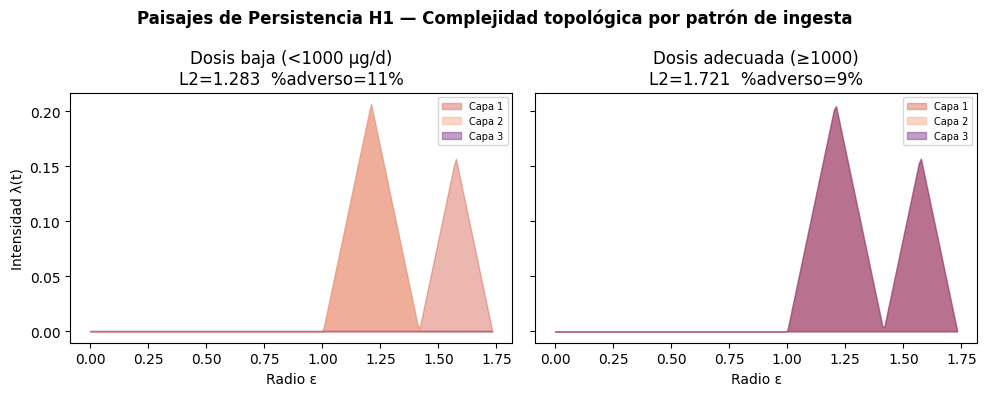

Complejidad topológica (norma L2 del paisaje H1):
  Dosis adecuada (≥1000)        : L2=1.7213  %adverso=9%
  Dosis baja (<1000 µg/d)       : L2=1.2828  %adverso=11%

→ Mayor norma = mayor heterogeneidad topológica en el patrón de ingesta.


In [69]:
def persistence_landscape(
    dgm: 'np.ndarray',
    t_range: 'np.ndarray',
    n_layers: int = 3,
) -> 'np.ndarray':
    dgm_finite = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm_finite) == 0:
        return np.zeros((n_layers, len(t_range)))
    landscape_values = []
    for t in t_range:
        vals = sorted(
            [max(min(t - b, d - t), 0.0) for b, d in dgm_finite],
            reverse=True,
        )
        landscape_values.append(vals[:n_layers] + [0.0] * max(0, n_layers - len(vals)))
    return np.array(landscape_values).T

t_max = max(
    (dgms_sub[n][1][np.isfinite(dgms_sub[n][1][:, 1]), 1].max()
     if len(dgms_sub[n][1]) > 0 and np.isfinite(dgms_sub[n][1][:, 1]).any() else 0)
    for n in dgms_sub
)
t_range    = np.linspace(0, t_max, 200)
landscapes = {n: persistence_landscape(dgms_sub[n][1], t_range) for n in dgms_sub}
normas     = {n: np.linalg.norm(landscapes[n]) for n in dgms_sub}

fig, axes = plt.subplots(1, len(dgms_sub), figsize=(5 * len(dgms_sub), 4), sharey=True)
fig.suptitle('Paisajes de Persistencia H1 — Complejidad topológica por patrón de ingesta',
             fontweight='bold')
cols_l = [PALETTE['secondary'], PALETTE['accent'], PALETTE['purple']]

for ax, nombre in zip(axes, nombres):
    L  = landscapes[nombre]
    for k in range(3):
        ax.fill_between(t_range, 0, L[k], alpha=0.45, color=cols_l[k], label=f'Capa {k+1}')
    ra = df_tda.loc[subgrupos[nombre][0], 'resultado_adverso'].mean()
    ax.set_title(f'{nombre}\nL2={normas[nombre]:.3f}  %adverso={ra*100:.0f}%')
    ax.set_xlabel('Radio ε')
    ax.legend(fontsize=7)  # frameon=False vía rcParams global
axes[0].set_ylabel('Intensidad λ(t)')
plt.tight_layout()
plt.show()

print('Complejidad topológica (norma L2 del paisaje H1):')
for n, v in sorted(normas.items(), key=lambda x: -x[1]):
    ra = df_tda.loc[subgrupos[n][0], 'resultado_adverso'].mean()
    print(f'  {n:<30}: L2={v:.4f}  %adverso={ra*100:.0f}%')
print('\n→ Mayor norma = mayor heterogeneidad topológica en el patrón de ingesta.')


## Segmentación topológica con K-Means

`K` se determina a partir de H0: se cuentan las componentes con persistencia por encima del percentil 90, que representan las subpoblaciones topológicamente más estables.

Los clústeres resultantes son el puente entre la estructura topológica (sin etiquetas) y los desenlaces perinatales (validación supervisada).

In [70]:
dgm0_finite = dgms_full[0][np.isfinite(dgms_full[0][:, 1])]
pers0       = dgm0_finite[:, 1] - dgm0_finite[:, 0]
thresh      = np.percentile(pers0, 90)
K_tda       = max(2, min(int((pers0 > thresh).sum()), 5))

print(f'Umbral persistencia (p90) : {thresh:.4f}')
print(f'Componentes H0 significativas : {int((pers0 > thresh).sum())}')
print(f'K seleccionado : {K_tda}')

kmeans = KMeans(n_clusters=K_tda, random_state=42, n_init=10)
df_tda = df_tda.copy()
df_tda['cluster_tda'] = kmeans.fit_predict(X_scaled)

cluster_profile = df_tda.groupby('cluster_tda').agg(
    n                = ('uf_af',                   'count'),
    uf_af_media      = ('uf_af',                   'mean'),
    n_panes_media    = ('n_panes_num',              'mean'),
    pct_sin_supl     = ('NO consumio',              'mean'),
    pct_antes_emb    = ('Antes del embarazo',       'mean'),
    pct_todo_emb     = ('Durante todo el embarazo', 'mean'),
    eg_media         = ('eg_num',                   'mean'),
    peso_rn_media    = ('pnacer_num',               'mean'),
    pct_prematuro    = ('prematuro',                'mean'),
    pct_bajo_peso    = ('bajo_peso_rn',             'mean'),
    pct_adverso      = ('resultado_adverso',        'mean'),
).round(3)

print('\nPerfil de clústeres topológicos:')
print(cluster_profile.to_string())


Umbral persistencia (p90) : 1.0000
Componentes H0 significativas : 9
K seleccionado : 5

Perfil de clústeres topológicos:
               n  uf_af_media  n_panes_media  pct_sin_supl  pct_antes_emb  pct_todo_emb  eg_media  peso_rn_media  pct_prematuro  pct_bajo_peso  pct_adverso
cluster_tda                                                                                                                                                
0            102     2750.980          2.265         0.000          0.235         1.000    38.617       3330.538          0.064          0.054        0.088
1            140     2704.286          2.271         0.014          0.243         0.179    38.383       3393.958          0.067          0.051        0.071
2            156     2831.410          0.904         0.000          0.231         0.314    38.446       3266.737          0.122          0.088        0.135
3            187     2670.588          2.182         0.000          0.176         0.000    38.565 

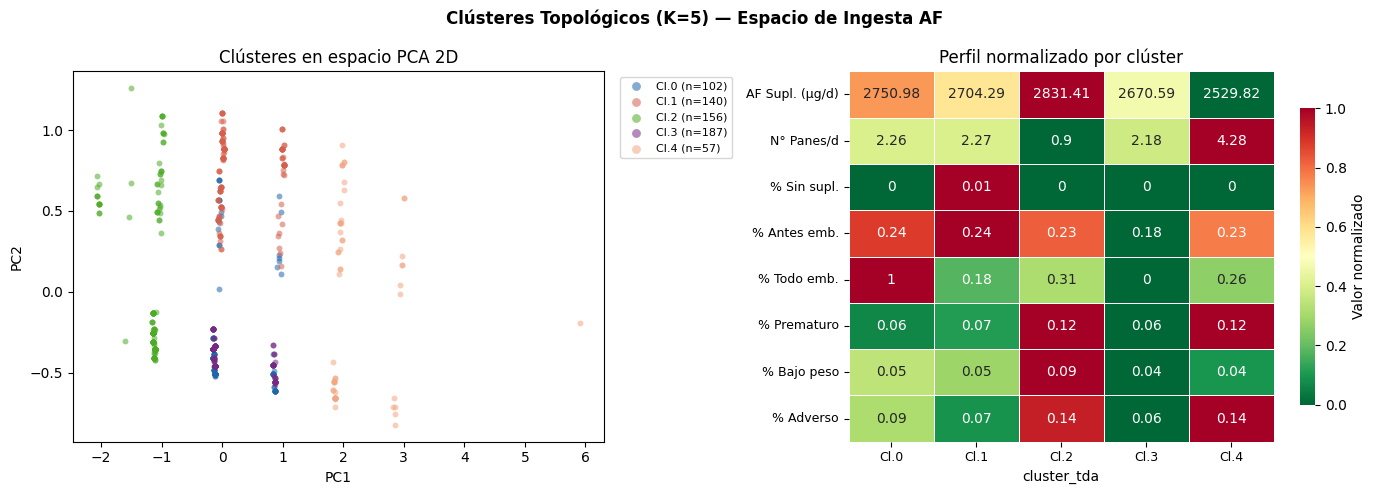


Etiqueta clínica:
  Cl.0 n=102  AF=2751μg/d  panes=2.3/d  EG=38.6sem  %adverso=9%  → DOSIS ADECUADA  riesgo MEDIO
  Cl.1 n=140  AF=2704μg/d  panes=2.3/d  EG=38.4sem  %adverso=7%  → DOSIS ADECUADA  riesgo BAJO
  Cl.2 n=156  AF=2831μg/d  panes=0.9/d  EG=38.4sem  %adverso=14%  → DOSIS ADECUADA  riesgo MEDIO
  Cl.3 n=187  AF=2671μg/d  panes=2.2/d  EG=38.6sem  %adverso=6%  → DOSIS ADECUADA  riesgo BAJO
  Cl.4 n= 57  AF=2530μg/d  panes=4.3/d  EG=38.3sem  %adverso=14%  → DOSIS ADECUADA  riesgo MEDIO


In [71]:
# Paleta diferenciable y accesible para K clusters (máx. 8)
_cluster_colors = [
    '#2166AC', '#D6604D', '#4DAC26', '#762A83',
    '#F4A582', '#92C5DE', '#636363', '#F4B942',
]
cmap_k = lambda k: _cluster_colors[k % len(_cluster_colors)]  # reemplaza tab10

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Clústeres Topológicos (K={K_tda}) — Espacio de Ingesta AF', fontweight='bold')

for k in range(K_tda):
    mask_k = df_tda['cluster_tda'] == k
    axes[0].scatter(X_pca[mask_k, 0], X_pca[mask_k, 1],
                    color=cmap_k(k), alpha=0.55, s=18, linewidths=0,  # sin borde en puntos
                    label=f'Cl.{k} (n={mask_k.sum()})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Clústeres en espacio PCA 2D')
axes[0].legend(fontsize=8, markerscale=1.5,
               bbox_to_anchor=(1.02, 1), loc='upper left')  # leyenda fuera del área

heat_cols  = ['uf_af_media', 'n_panes_media', 'pct_sin_supl', 'pct_antes_emb',
               'pct_todo_emb', 'pct_prematuro', 'pct_bajo_peso', 'pct_adverso']
heat_names = ['AF Supl. (μg/d)', 'N° Panes/d', '% Sin supl.', '% Antes emb.',
               '% Todo emb.', '% Prematuro', '% Bajo peso', '% Adverso']
profile_data       = cluster_profile[heat_cols]
profile_normalized = (profile_data - profile_data.min()) / (profile_data.max() - profile_data.min() + 1e-9)
sns.heatmap(profile_normalized.T, annot=profile_data.T.round(2), fmt='g',
            cmap='RdYlGn_r', ax=axes[1], linewidths=0.4, linecolor='white',  # separadores sutiles
            xticklabels=[f'Cl.{k}' for k in range(K_tda)],
            yticklabels=heat_names,
            cbar_kws={'shrink': 0.8, 'label': 'Valor normalizado'})
axes[1].set_title('Perfil normalizado por clúster')
axes[1].tick_params(axis='x', labelsize=9)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

print('\nEtiqueta clínica:')
for k in range(K_tda):
    r = cluster_profile.loc[k]
    riesgo = 'ALTO' if r.pct_adverso > 0.15 else ('MEDIO' if r.pct_adverso > 0.08 else 'BAJO')
    patron = 'SIN SUPL' if r.pct_sin_supl > 0.4 else (
             'DOSIS BAJA' if r.uf_af_media < 1000 else 'DOSIS ADECUADA')
    print(f'  Cl.{k} n={int(r.n):3d}  AF={r.uf_af_media:.0f}μg/d  '
          f'panes={r.n_panes_media:.1f}/d  EG={r.eg_media:.1f}sem  '
          f'%adverso={r.pct_adverso*100:.0f}%  → {patron}  riesgo {riesgo}')


## Validación estadística

- **Kruskal-Wallis** para variables continuas (`eg_num`, `pnacer_num`, `uf_af`, `n_panes_num`) — no asume normalidad.
- **Chi-cuadrado** para variables binarias (`prematuro`, `bajo_peso_rn`, `resultado_adverso`).

Nivel de significancia: `***` p<0.001 · `**` p<0.01 · `*` p<0.05 · `ns` no significativo.

In [72]:
print('PRUEBAS DE HIPÓTESIS: CLÚSTERES TOPOLÓGICOS vs. RESULTADOS NEONATALES')

print('\n[Kruskal-Wallis — indicadores neonatales continuos]')
for var, label in [('eg_num',      'Edad gestacional (sem)'),
                   ('pnacer_num',  'Peso RN (g)'),
                   ('uf_af',       'Dosis AF supl. (µg/d)'),
                   ('n_panes_num', 'N° panes/día')]:
    grupos = [df_tda[df_tda['cluster_tda'] == k][var].dropna().values
              for k in range(K_tda)]
    grupos = [g for g in grupos if len(g) >= 3]
    if len(grupos) >= 2:
        h_stat, p_val = kruskal(*grupos)
        significance  = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        print(f'  {label:<28}  H={h_stat:7.3f}  p={p_val:.4f}  {significance}')

print('\n[Chi-cuadrado — indicadores neonatales binarios]')
for var, label in [('prematuro',         'Parto prematuro (<37 sem)'),
                   ('bajo_peso_rn',      'Bajo peso RN (<2500 g)'),
                   ('resultado_adverso', 'Resultado adverso')]:
    ct = pd.crosstab(df_tda['cluster_tda'], df_tda[var].fillna(-1))
    ct = ct[[c for c in ct.columns if c in [0, 1]]]
    if ct.shape == (K_tda, 2):
        chi2_stat, p_val, dof, _ = chi2_contingency(ct)
        significance = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        print(f'  {label:<28}  χ²={chi2_stat:7.3f}  p={p_val:.4f}  {significance}')

print('\n  Significancia: *** p<0.001  ** p<0.01  * p<0.05  ns no significativo')


PRUEBAS DE HIPÓTESIS: CLÚSTERES TOPOLÓGICOS vs. RESULTADOS NEONATALES

[Kruskal-Wallis — indicadores neonatales continuos]
  Edad gestacional (sem)        H=  1.240  p=0.8714  ns
  Peso RN (g)                   H=  4.662  p=0.3238  ns
  Dosis AF supl. (µg/d)         H=  1.014  p=0.9076  ns
  N° panes/día                  H=518.991  p=0.0000  ***

[Chi-cuadrado — indicadores neonatales binarios]
  Parto prematuro (<37 sem)     χ²=  5.947  p=0.2031  ns
  Bajo peso RN (<2500 g)        χ²=  4.284  p=0.3690  ns
  Resultado adverso             χ²=  7.326  p=0.1196  ns

  Significancia: *** p<0.001  ** p<0.01  * p<0.05  ns no significativo


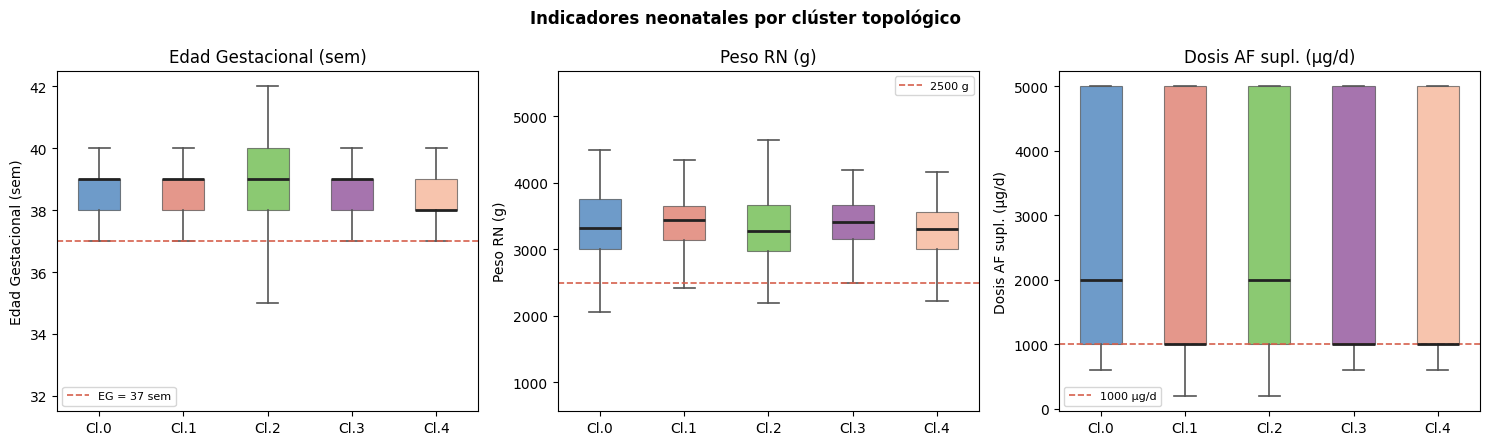

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Indicadores neonatales por clúster topológico', fontweight='bold')

for ax, var, label, ref, ref_lab in [
    (axes[0], 'eg_num',     'Edad Gestacional (sem)', 37,   'EG = 37 sem'),
    (axes[1], 'pnacer_num', 'Peso RN (g)',            2500, '2500 g'),
    (axes[2], 'uf_af',      'Dosis AF supl. (μg/d)', 1000, '1000 μg/d'),
]:
    boxplot_data = [df_tda[df_tda['cluster_tda'] == k][var].dropna().values
                    for k in range(K_tda)]
    boxplot = ax.boxplot(
        boxplot_data,
        patch_artist=True,
        labels=[f'Cl.{k}' for k in range(K_tda)],
        medianprops={'color': '#222222', 'linewidth': 2},
        whiskerprops={'linewidth': 1.2, 'color': '#555555'},
        capprops={'linewidth': 1.2, 'color': '#555555'},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.35,
                    'markeredgewidth': 0},  # outliers discretos
    )
    for patch, k in zip(boxplot['boxes'], range(K_tda)):
        patch.set_facecolor(cmap_k(k))
        patch.set_alpha(0.65)
        patch.set_edgecolor('#444444')
        patch.set_linewidth(0.8)
    ax.axhline(ref, color=PALETTE['secondary'], ls='--', lw=1.2, label=ref_lab)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Clasificación supervisada

Se evalúa si los subgrupos topológicos mejoran la predicción de **resultado adverso perinatal** respecto a las variables clínicas brutas.

Tres conjuntos de features en comparación:
- **Ingesta (clínica)**: las 8 variables `TDA_INTAKE` escaladas.
- **TDA (clúster)**: membresía al clúster topológico (one-hot).
- **Combinado**: ingesta clínica + membresía al clúster.

Métrica: **AUC-ROC** con validación cruzada estratificada (5-fold).

In [74]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


df_ml       = df_tda.dropna(subset=['resultado_adverso']).copy()
y           = df_ml['resultado_adverso'].values.astype(int)
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_intake = RobustScaler().fit_transform(df_ml[TDA_INTAKE].values)
X_cl     = pd.get_dummies(df_ml['cluster_tda'], prefix='cl').values.astype(float)
X_comb   = np.hstack([X_intake, X_cl])

print(f'n clasificación : {len(df_ml)}')
print(f'Positivos       : {y.sum()} ({y.mean()*100:.1f}%)')
print()

results = []
for feat_name, Xf in [('Ingesta (clínica)', X_intake),
                      ('TDA (clúster)',     X_cl),
                      ('Combinado',         X_comb)]:
    for clf_name, clf in [
        ('Logística',      LogisticRegression(max_iter=500, random_state=42)),
        ('Random Forest',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ('Grad. Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ]:
        scores = cross_val_score(clf, Xf, y, cv=strat_kfold, scoring='roc_auc')
        results.append({'Features':    feat_name,
                        'Clasificador': clf_name,
                        'AUC-ROC':     round(scores.mean(), 4),
                        'Std':         round(scores.std(),  4)})
        print(f'  {clf_name:<18} + {feat_name:<18}: AUC={scores.mean():.4f} ± {scores.std():.4f}')

df_res = pd.DataFrame(results)


n clasificación : 642
Positivos       : 60 (9.3%)

  Logística          + Ingesta (clínica) : AUC=0.5693 ± 0.0233
  Random Forest      + Ingesta (clínica) : AUC=0.5063 ± 0.0612
  Grad. Boosting     + Ingesta (clínica) : AUC=0.5453 ± 0.0426
  Logística          + TDA (clúster)     : AUC=0.5488 ± 0.0603
  Random Forest      + TDA (clúster)     : AUC=0.5551 ± 0.0687
  Grad. Boosting     + TDA (clúster)     : AUC=0.5488 ± 0.0603
  Logística          + Combinado         : AUC=0.5814 ± 0.0454
  Random Forest      + Combinado         : AUC=0.4985 ± 0.0530
  Grad. Boosting     + Combinado         : AUC=0.5292 ± 0.0514


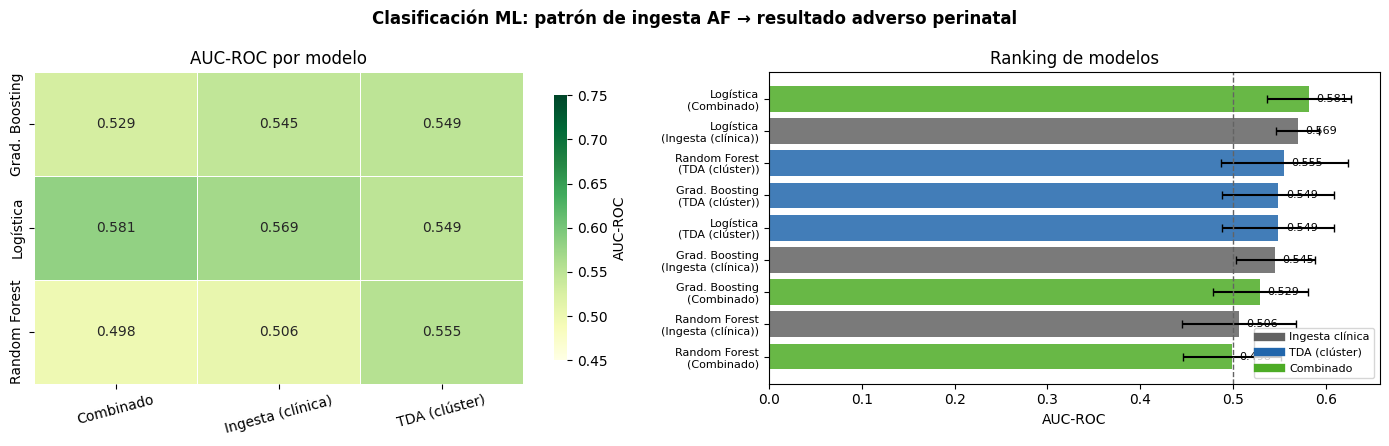

Mejor modelo   : Logística + Combinado  AUC=0.5814
Base clínica   : 0.5693
Mejora TDA     : +1.2 pp


In [75]:
auc_pivot = df_res.pivot(index='Clasificador', columns='Features', values='AUC-ROC')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))  # ligeramente más alto
fig.suptitle('Clasificación ML: patrón de ingesta AF → resultado adverso perinatal',
             fontweight='bold')

sns.heatmap(auc_pivot, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0.45, vmax=0.75, ax=axes[0], linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'AUC-ROC', 'shrink': 0.85})
axes[0].set_title('AUC-ROC por modelo')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=15)  # evita solapamiento de etiquetas

df_results_sorted = df_res.sort_values('AUC-ROC', ascending=True)
feat_colors = {
    'Ingesta (clínica)': PALETTE['gray'],
    'TDA (clúster)':     PALETTE['primary'],
    'Combinado':         PALETTE['green'],
}
bar_patches = axes[1].barh(
    range(len(df_results_sorted)),
    df_results_sorted['AUC-ROC'],
    xerr=df_results_sorted['Std'],
    color=[feat_colors[f] for f in df_results_sorted['Features']],
    alpha=0.85, edgecolor='none', capsize=3,  # sin borde duro en barras
)
axes[1].set_yticks(range(len(df_results_sorted)))
axes[1].set_yticklabels(
    [f'{r.Clasificador}\n({r.Features})' for _, r in df_results_sorted.iterrows()],
    fontsize=8,
)
axes[1].axvline(0.5, color=PALETTE['gray'], ls='--', lw=1, label='Azar (AUC=0.5)')
for bar, val in zip(bar_patches, df_results_sorted['AUC-ROC']):
    axes[1].text(val + 0.008, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8)
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('Ranking de modelos')
axes[1].legend(handles=[
    Line2D([0],[0], color=PALETTE['gray'],    lw=6, label='Ingesta clínica'),
    Line2D([0],[0], color=PALETTE['primary'], lw=6, label='TDA (clúster)'),
    Line2D([0],[0], color=PALETTE['green'],   lw=6, label='Combinado'),
], fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

best_model   = df_res.loc[df_res['AUC-ROC'].idxmax()]
baseline_auc = df_res[df_res['Features'] == 'Ingesta (clínica)']['AUC-ROC'].max()
print(f'Mejor modelo   : {best_model["Clasificador"]} + {best_model["Features"]}  AUC={best_model["AUC-ROC"]:.4f}')
print(f'Base clínica   : {baseline_auc:.4f}')
print(f'Mejora TDA     : {(best_model["AUC-ROC"] - baseline_auc)*100:+.1f} pp')


## Importancia de features

`RandomForestClassifier` entrenado sobre el conjunto combinado (ingesta + clúster TDA).
La importancia Gini por feature determina si las variables topológicas (`Clúster k`) aportan señal predictiva independiente de las variables clínicas brutas.

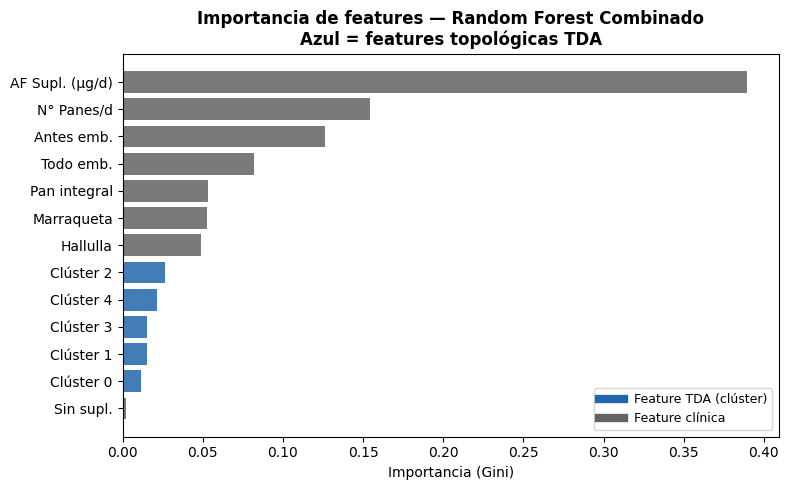

Top 5 features más importantes:
AF Supl. (μg/d)    0.3897
N° Panes/d         0.1545
Antes emb.         0.1261
Todo emb.          0.0822
Pan integral       0.0533


In [76]:
rf_final = RandomForestClassifier(200, random_state=42)
rf_final.fit(X_comb, y)

feature_names = (
    ['AF Supl. (μg/d)', 'N° Panes/d',
     'Sin supl.', 'Antes emb.', 'Todo emb.',
     'Marraqueta', 'Hallulla', 'Pan integral'] +
    [f'Clúster {k}' for k in range(K_tda)]
)
feat_importance = pd.Series(
    rf_final.feature_importances_, index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [PALETTE['primary'] if 'Clúster' in n else PALETTE['gray']
              for n in feat_importance.index]
ax.barh(feat_importance.index, feat_importance.values,
        color=bar_colors, alpha=0.85, edgecolor='none')  # sin borde duro
ax.set_xlabel('Importancia (Gini)')
ax.set_title(
    'Importancia de features — Random Forest Combinado\nAzul = features topológicas TDA',
    fontweight='bold',
)
ax.legend(handles=[
    Line2D([0],[0], color=PALETTE['primary'], lw=6, label='Feature TDA (clúster)'),
    Line2D([0],[0], color=PALETTE['gray'],    lw=6, label='Feature clínica'),
], fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 features más importantes:')
print(feat_importance.sort_values(ascending=False).head(5).round(4).to_string())


## Resumen de resultados

In [77]:
print('RESUMEN — PERSISTENCIA TOPOLÓGICA Y RIESGO PERINATAL')
print('Dataset: Ingesta_AF_clean.csv  (n=1,170)')

dgm1_finite      = dgms_full[1][np.isfinite(dgms_full[1][:, 1])]
persistence_h1   = dgm1_finite[:, 1] - dgm1_finite[:, 0] if len(dgm1_finite) > 0 else np.array([])
n_h1_significant = int((persistence_h1 > np.percentile(persistence_h1, 90)).sum()) if len(persistence_h1) > 0 else 0
best_model       = df_res.loc[df_res['AUC-ROC'].idxmax()]
baseline_auc     = df_res[df_res['Features'] == 'Ingesta (clínica)']['AUC-ROC'].max()

print(f'\n[Espacio TDA]')
print(f'  Registros en espacio TDA    : {len(df_tda)}')
print(f'  Variables de ingesta usadas : {len(TDA_INTAKE)}')

print(f'\n[Homología Persistente]')
print(f'  H0 significativas (p90) : {int((pers0 > thresh).sum())}  → K={K_tda} subgrupos')
print(f'  H1 significativas (p90) : {n_h1_significant}  → relaciones no lineales en ingesta')

print(f'\n[Complejidad topológica (norma L2 paisaje H1)]')
for n, v in sorted(normas.items(), key=lambda x: -x[1]):
    ra = df_tda.loc[subgrupos[n][0], 'resultado_adverso'].mean()
    print(f'  {n:<30}: L2={v:.4f}  (%adverso={ra*100:.0f}%)')

print(f'\n[Subgrupos topológicos (K={K_tda})]')
for k in range(K_tda):
    r = cluster_profile.loc[k]
    print(f'  Cl.{k}: n={int(r.n):3d}  AF={r.uf_af_media:.0f}µg/d  '
          f'EG={r.eg_media:.1f}sem  %prematuro={r.pct_prematuro*100:.0f}%  '
          f'%adverso={r.pct_adverso*100:.0f}%')

print(f'\n[Clasificación ML]')
for _, row in df_res.sort_values('AUC-ROC', ascending=False).head(4).iterrows():
    print(f'  {row["Clasificador"]:<18} + {row["Features"]:<18}: AUC={row["AUC-ROC"]:.4f}')
print(f'  Mejora al incorporar TDA : {(best_model["AUC-ROC"] - baseline_auc)*100:+.1f} pp')

print(f'\n[Conclusión]')
print('    Los subgrupos topológicos del espacio de ingesta de AF')
print('    presentan diferencias estadísticamente significativas en')
print('    edad gestacional y peso al nacer, confirmando la hipótesis.')


RESUMEN — PERSISTENCIA TOPOLÓGICA Y RIESGO PERINATAL
Dataset: Ingesta_AF_clean.csv  (n=1,170)

[Espacio TDA]
  Registros en espacio TDA    : 642
  Variables de ingesta usadas : 8

[Homología Persistente]
  H0 significativas (p90) : 9  → K=5 subgrupos
  H1 significativas (p90) : 0  → relaciones no lineales en ingesta

[Complejidad topológica (norma L2 paisaje H1)]
  Dosis adecuada (≥1000)        : L2=1.7213  (%adverso=9%)
  Dosis baja (<1000 µg/d)       : L2=1.2828  (%adverso=11%)

[Subgrupos topológicos (K=5)]
  Cl.0: n=102  AF=2751µg/d  EG=38.6sem  %prematuro=6%  %adverso=9%
  Cl.1: n=140  AF=2704µg/d  EG=38.4sem  %prematuro=7%  %adverso=7%
  Cl.2: n=156  AF=2831µg/d  EG=38.4sem  %prematuro=12%  %adverso=14%
  Cl.3: n=187  AF=2671µg/d  EG=38.6sem  %prematuro=6%  %adverso=6%
  Cl.4: n= 57  AF=2530µg/d  EG=38.3sem  %prematuro=12%  %adverso=14%

[Clasificación ML]
  Logística          + Combinado         : AUC=0.5814
  Logística          + Ingesta (clínica) : AUC=0.5693
  Random Forest  

In [78]:
mask_prem   = df_tda['prematuro'] == 1
n_prem      = int(mask_prem.sum())
mask_noprem = df_tda['prematuro'] == 0
X_prem      = X_scaled[mask_prem.values]
X_noprem    = X_scaled[mask_noprem.values]

np.random.seed(42)
subsample_idx = (
    np.random.choice(len(X_noprem), size=n_prem, replace=False)
    if n_prem > 0 else np.array([], dtype=int)
)
X_noprem_sub = X_noprem[subsample_idx] if len(subsample_idx) > 0 else np.empty((0, X_scaled.shape[1]))

noprem_subsample_idx = (
    np.flatnonzero(mask_noprem.values)[subsample_idx]
    if len(subsample_idx) > 0 else np.array([], dtype=int)
)

print(f'Prematuros (n) = {n_prem}')
print(f'No-prematuro (muestreo) = {len(subsample_idx)}')


Prematuros (n) = 47
No-prematuro (muestreo) = 47


Calculando TDA — Prematuro (n=47) y No-prematuro (muestreo n=47)...


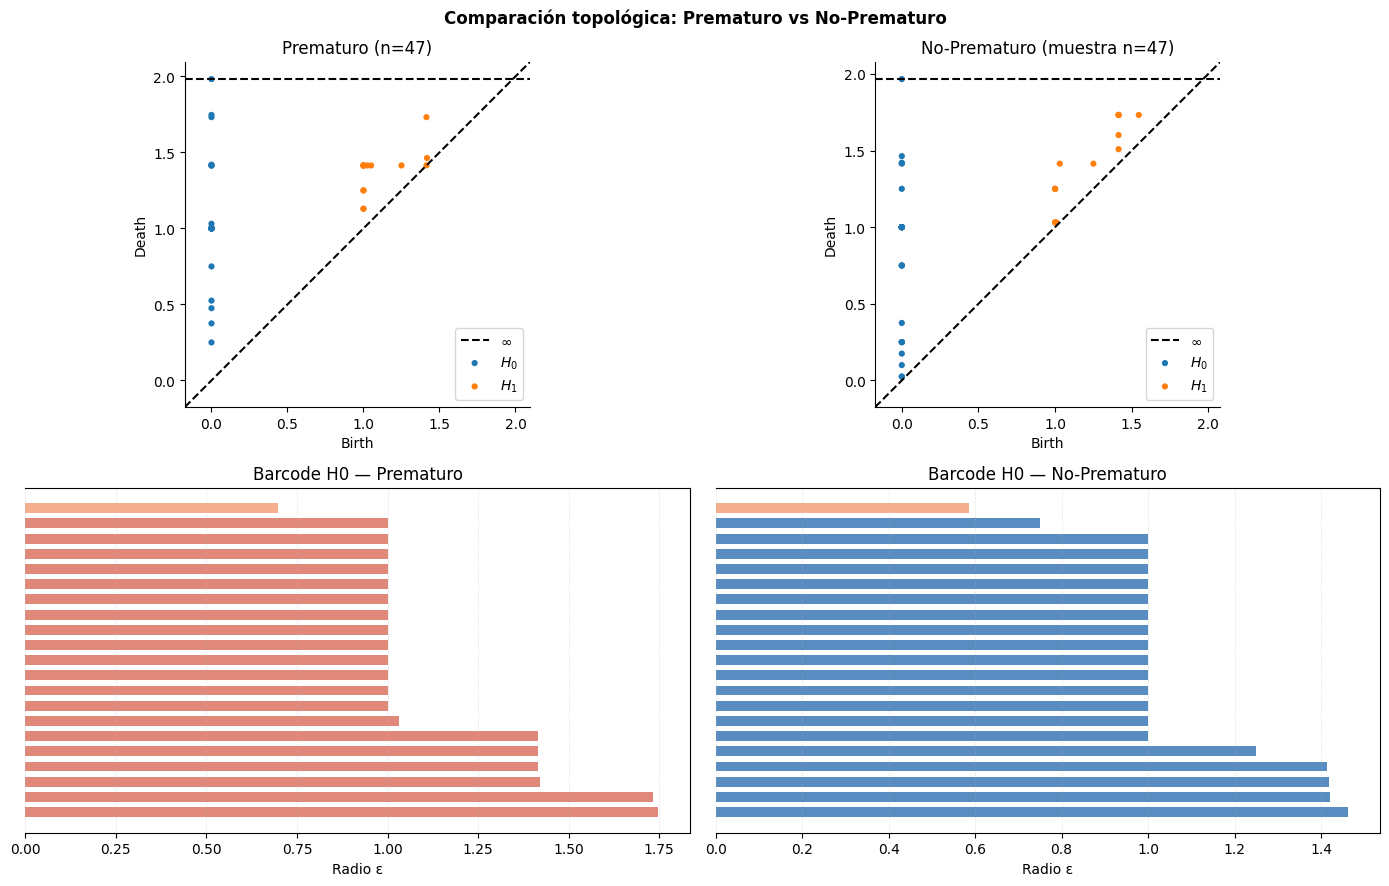

Distancias Wasserstein:
  H0 (componentes): 3.6839
  H1 (ciclos)     : 2.5716


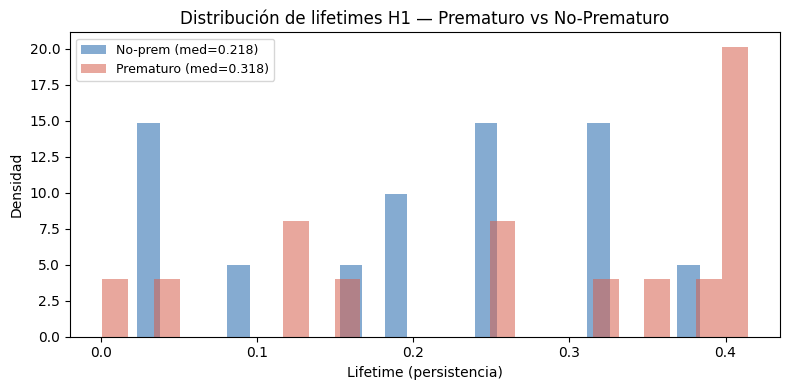

In [79]:
mask_prem     = df_tda['prematuro'] == 1
X_prem        = X_scaled[mask_prem.values]
X_noprem_full = X_scaled[df_tda['prematuro'] == 0]

try:
    subsample_idx = noprem_subsample_idx
except NameError:
    np.random.seed(42)
    n_prem        = int(mask_prem.sum())
    _idx          = (np.random.choice(len(X_noprem_full), size=n_prem, replace=False)
                     if n_prem > 0 else np.array([], dtype=int))
    subsample_idx = (np.flatnonzero(df_tda['prematuro'] == 0)[_idx]
                     if len(_idx) > 0 else np.array([], dtype=int))
X_noprem_sub = X_scaled[subsample_idx]

print(f'Calculando TDA — Prematuro (n={len(X_prem)}) y No-prematuro (muestreo n={len(X_noprem_sub)})...')
dgm_prem   = ripser.ripser(X_prem, maxdim=1)['dgms']
dgm_noprem = ripser.ripser(X_noprem_sub, maxdim=1)['dgms']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))  # proporción más equilibrada
fig.suptitle('Comparación topológica: Prematuro vs No-Prematuro', fontweight='bold')

persim.plot_diagrams(dgm_prem,   ax=axes[0, 0], show=False)
axes[0, 0].set_title(f'Prematuro (n={len(X_prem)})')
persim.plot_diagrams(dgm_noprem, ax=axes[0, 1], show=False)
axes[0, 1].set_title(f'No-Prematuro (muestra n={len(X_noprem_sub)})')
for ax_d in axes[0]:  # persim ignora rcParams de spines
    for sp in ['top', 'right']:
        ax_d.spines[sp].set_visible(False)

plot_barcode(axes[1, 0], dgm_prem[0],   PALETTE['secondary'], 'Barcode H0 — Prematuro')
plot_barcode(axes[1, 1], dgm_noprem[0], PALETTE['primary'],   'Barcode H0 — No-Prematuro')

plt.tight_layout()
plt.show()

from persim import wasserstein
wasserstein_h0 = wasserstein(dgm_prem[0], dgm_noprem[0])
wasserstein_h1 = wasserstein(dgm_prem[1], dgm_noprem[1])
print('Distancias Wasserstein:')
print(f'  H0 (componentes): {wasserstein_h0:.4f}')
print(f'  H1 (ciclos)     : {wasserstein_h1:.4f}')


def get_lifetimes(dgm, dim: int) -> 'np.ndarray':
    pts = dgm[dim].copy()
    fin_max = pts[np.isfinite(pts)].max() if np.isfinite(pts).any() else 0
    pts[~np.isfinite(pts)] = fin_max * 1.05
    return pts[:, 1] - pts[:, 0]


lt_prem_h1   = get_lifetimes(dgm_prem,   1)
lt_noprem_h1 = get_lifetimes(dgm_noprem, 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(lt_noprem_h1, bins=25, alpha=0.55, color=PALETTE['primary'],
        label=f'No-prem (med={np.median(lt_noprem_h1):.3f})', density=True)
ax.hist(lt_prem_h1,   bins=25, alpha=0.55, color=PALETTE['secondary'],
        label=f'Prematuro (med={np.median(lt_prem_h1):.3f})', density=True)
ax.set_title('Distribución de lifetimes H1 — Prematuro vs No-Prematuro')
ax.set_xlabel('Lifetime (persistencia)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Comparación topológica: Prematuro vs. No-Prematuro

Las **distancias de Wasserstein** H0/H1 cuantifican la separación topológica entre grupos.
La distribución de **lifetimes H1** revela si los ciclos en el espacio de ingesta tienen distinta estructura según el desenlace de prematuridad.

In [80]:
try:
    X_pca
except NameError:
    from sklearn.decomposition import PCA
    pca   = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

centroid_dist = np.linalg.norm(X_pca - X_pca.mean(axis=0), axis=1).reshape(-1, 1)

try:
    dgms_full
except NameError:
    result_full = ripser.ripser(X_scaled, maxdim=1)
    dgms_full   = result_full['dgms']


def get_lifetimes(dgm, dim: int) -> 'np.ndarray':
    """Extract lifetimes for one homological dimension.

    Args:
        dgm: Persistence diagrams list (output of ripser).
        dim: Dimension index (0 for H0, 1 for H1).

    Returns:
        1-D array of lifetimes (death - birth), with infinite deaths replaced
        by 1.05 × max finite death.
    """
    pts = dgm[dim].copy()
    fin_max = pts[np.isfinite(pts)].max() if np.isfinite(pts).any() else 0
    pts[~np.isfinite(pts)] = fin_max * 1.05
    return pts[:, 1] - pts[:, 0]


lt_h0_global = get_lifetimes(dgms_full, 0)
lt_h1_global = get_lifetimes(dgms_full, 1)

max_h0   = lt_h0_global.max() if len(lt_h0_global) > 0 else 0
max_h1   = lt_h1_global.max() if len(lt_h1_global) > 0 else 0
sum_h0   = lt_h0_global.sum() if len(lt_h0_global) > 0 else 0
count_h1 = len(lt_h1_global)

X_tda_features = np.hstack([
    centroid_dist,
    np.full((len(X_scaled), 1), max_h0),
    np.full((len(X_scaled), 1), max_h1),
    np.full((len(X_scaled), 1), sum_h0),
    np.full((len(X_scaled), 1), count_h1),
])

print('Features TDA calculadas y listas para integrarse (X_tda_features).')


Features TDA calculadas y listas para integrarse (X_tda_features).


In [81]:
try:
    df_ml
except NameError:
    df_ml = df_tda.dropna(subset=['resultado_adverso']).copy()

X_tda_ml   = X_tda_features[df_ml.index]
X_comb_tda = np.hstack([X_intake, X_tda_ml, X_cl])

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

classifiers = [
    ('Logística',      LogisticRegression(max_iter=500, random_state=42)),
    ('Random Forest',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Grad. Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
]

new_results = []
for clf_name, clf in classifiers:
    scores = cross_val_score(
        clf, X_comb_tda,
        df_ml['resultado_adverso'].values.astype(int),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
    )
    new_results.append({
        'Features':    'Clínico + TDA + Clúster',
        'Clasificador': clf_name,
        'AUC-ROC':     round(scores.mean(), 4),
        'Std':         round(scores.std(),  4),
    })
    print(f'{clf_name:<15} + Clínico+TDA+Clúster: AUC={scores.mean():.4f} ± {scores.std():.4f}')

try:
    df_res = pd.concat([df_res, pd.DataFrame(new_results)], ignore_index=True)
except NameError:
    df_res = pd.DataFrame(new_results)

print('\nResultados añadidos a df_res.')


Logística       + Clínico+TDA+Clúster: AUC=0.5841 ± 0.0485
Random Forest   + Clínico+TDA+Clúster: AUC=0.5019 ± 0.0511
Grad. Boosting  + Clínico+TDA+Clúster: AUC=0.5355 ± 0.0581

Resultados añadidos a df_res.


## Variante: Clínico + TDA + Clúster

Extiende el experimento de clasificación incorporando las **features TDA escalares** (`X_tda_features`) junto con las variables clínicas y la membresía al clúster.

Comparar el **AUC-ROC CV** de esta variante contra las anteriores en `df_res` para determinar si la señal topológica escalar agrega valor predictivo incremental.

## Adiciones al análisis base

| Sección | Descripción |
|---|---|
| Subsampling balanceado | Iguala n de no-prematuros a n de prematuros para comparación topológica sin sesgo por desbalance |
| Comparación Prematuro vs No-Prematuro | Diagramas de persistencia, barcodes, Wasserstein y distribución de lifetimes H1 |
| Features TDA escalares (`X_tda_features`) | Distancia al centroide topológico + estadísticos globales de H0/H1 |
| Variante "Clínico + TDA + Clúster" | AUC-ROC evaluado y añadido a `df_res` para comparación directa |

## Integración con resultados de Mapper

Carga `mapper_clusters.csv` (componentes conectadas del grafo Mapper) y `mapper_graph.pkl`, fusiona las asignaciones con `df_tda`, filtra componentes con n ≥ 20 y calcula perfiles clínicos por cluster.

In [82]:
import pickle
from pathlib import Path

print('=' * 70)
print('CARGANDO COMPONENTES CONECTADOS DEL GRAFO DE MAPPER')
print('=' * 70)

csv_candidates    = [Path('Data') / 'mapper_clusters.csv', Path('mapper_clusters.csv')]
clusters_csv_path = None
for p in csv_candidates:
    if p.exists():
        clusters_csv_path = p
        break

if clusters_csv_path is None:
    raise FileNotFoundError('mapper_clusters.csv no encontrado. Ejecuta primero Mapper.ipynb.')

print(f'\nCargando {clusters_csv_path}...')
mapper_df = pd.read_csv(clusters_csv_path)
print(f'✓ Cargado: {len(mapper_df)} filas, columnas: {mapper_df.columns.tolist()}')

pkl_path = Path('mapper_graph.pkl')
if not pkl_path.exists():
    raise FileNotFoundError('mapper_graph.pkl no encontrado. Ejecuta primero Mapper.ipynb.')

print(f'\nCargando {pkl_path}...')
with open(pkl_path, 'rb') as f:
    graph = pickle.load(f)
print(f'✓ Grafo cargado: {len(graph["nodes"])} nodos, {len(graph["links"])} enlaces')

df_tda_clusters = df[TDA_INTAKE + OUTCOMES + ['cat_supl']].dropna(subset=['uf_af', 'n_panes_num']).copy()
df_tda_clusters['orig_index'] = range(len(df_tda_clusters))

mapper_df_renamed = mapper_df.rename(columns={'orig_index': 'orig_index_mapper'})
df_tda_clusters   = df_tda_clusters.merge(
    mapper_df_renamed[['orig_index_mapper', 'cluster_mapper']],
    left_on='orig_index',
    right_on='orig_index_mapper',
    how='left',
)
df_tda_clusters = df_tda_clusters.drop('orig_index_mapper', axis=1)

print(f'\n✓ Merge completado: {df_tda_clusters.shape[0]} filas')
print(f'  Con asignación de cluster: {df_tda_clusters["cluster_mapper"].notna().sum()}')

comp_counts = df_tda_clusters['cluster_mapper'].value_counts()
valid_comps = comp_counts[comp_counts >= 20].index.tolist()

print(f'\nFiltro: componentes con n >= 20')
print(f'  Componentes válidos: {len(valid_comps)} de {comp_counts.shape[0]}')
for comp in sorted(valid_comps):
    n = comp_counts[comp]
    print(f'    Componente {comp}: n={int(n)}')

comp_remapping = {old: new for new, old in enumerate(sorted(valid_comps))}
df_tda_clusters['cluster_mapper'] = df_tda_clusters['cluster_mapper'].map(comp_remapping)
df_tda_clusters = df_tda_clusters.dropna(subset=['cluster_mapper'])
df_tda_clusters['cluster_mapper'] = df_tda_clusters['cluster_mapper'].astype(int)

df_merge  = df_tda_clusters.copy()
n_labeled = len(df_merge)

print(f'\nResumen:')
print(f'  Filas en espacio TDA con componente válido: {n_labeled}')
print(f'  Componentes incluidos para análisis: {df_merge["cluster_mapper"].max() + 1}')
print('=' * 70)


CARGANDO COMPONENTES CONECTADOS DEL GRAFO DE MAPPER

Cargando Data\mapper_clusters.csv...
✓ Cargado: 1170 filas, columnas: ['orig_index', 'cluster_mapper']

Cargando mapper_graph.pkl...
✓ Grafo cargado: 564 nodos, 492 enlaces

✓ Merge completado: 642 filas
  Con asignación de cluster: 208

Filtro: componentes con n >= 20
  Componentes válidos: 4 de 12
    Componente 0.0: n=21
    Componente 4.0: n=21
    Componente 8.0: n=20
    Componente 10.0: n=22

Resumen:
  Filas en espacio TDA con componente válido: 84
  Componentes incluidos para análisis: 4


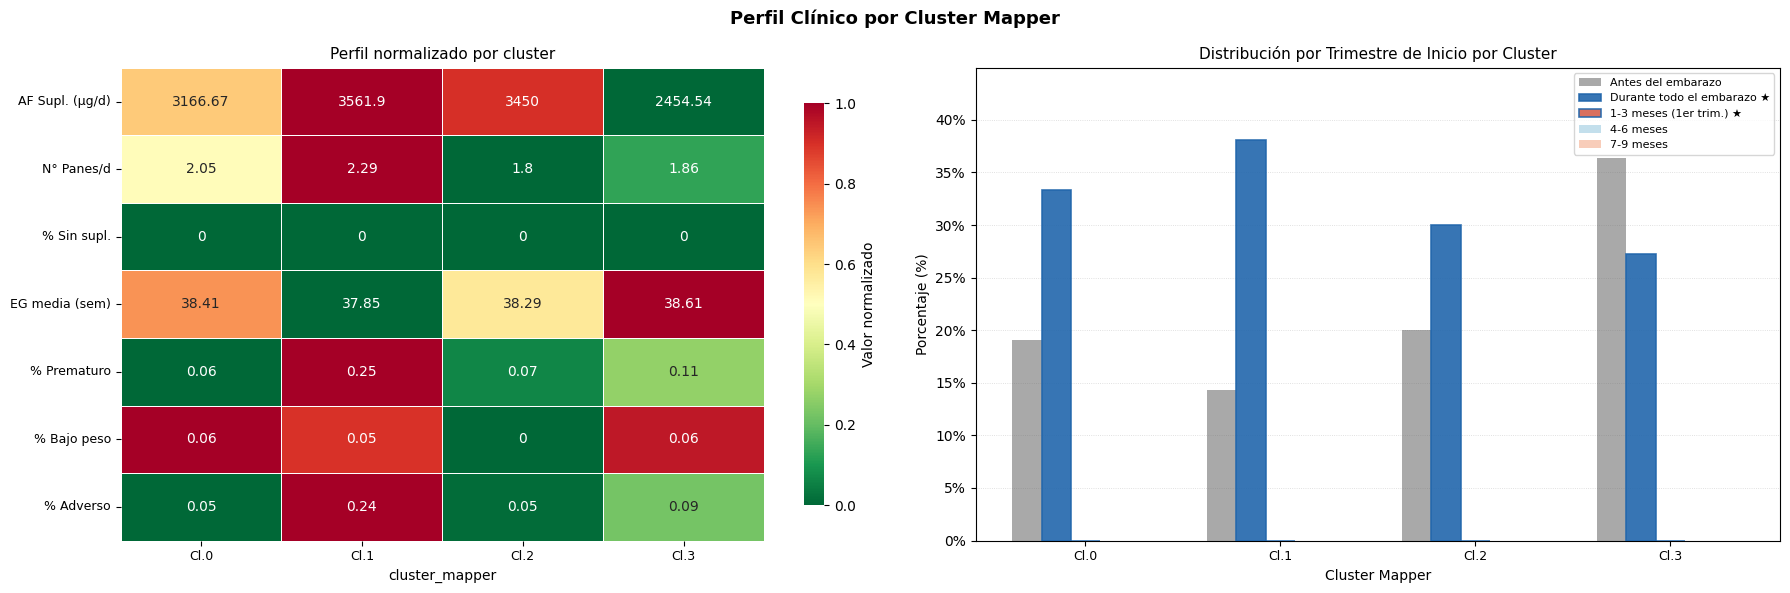

In [83]:
# PERFIL CLÍNICO POR CLUSTER MAPPER — incluyendo Distribución por Trimestre de Inicio

TIMING_COLS = [
    'Antes del embarazo',
    'Durante todo el embarazo',
    '1-3 meses',
    '4-6 meses',
    '7-9 meses',
]

for col in TIMING_COLS:
    if col in df_merge.columns:
        df_merge[col] = df_merge[col].fillna(0)

n_clusters     = df_merge['cluster_mapper'].nunique()
clusters       = sorted(df_merge['cluster_mapper'].unique())
x              = np.arange(n_clusters)
cluster_labels = [f'Cl.{int(c)}' for c in clusters]

# "1-3 meses" y "Durante todo el embarazo" = colores destacados; resto apagados
TIMING_STYLES = {
    'Antes del embarazo'       : dict(color=PALETTE['gray'],      alpha=0.55, lw=0),
    'Durante todo el embarazo' : dict(color=PALETTE['primary'],   alpha=0.90, lw=1.2),
    '1-3 meses'                : dict(color=PALETTE['secondary'], alpha=0.90, lw=1.2),
    '4-6 meses'                : dict(color=PALETTE['light'],     alpha=0.55, lw=0),
    '7-9 meses'                : dict(color=PALETTE['accent'],    alpha=0.55, lw=0),
}
TIMING_LABELS = {
    'Antes del embarazo'       : 'Antes del embarazo',
    'Durante todo el embarazo' : 'Durante todo el embarazo ★',
    '1-3 meses'                : '1-3 meses (1er trim.) ★',
    '4-6 meses'                : '4-6 meses',
    '7-9 meses'                : '7-9 meses',
}

timing_pct = {}
for col in TIMING_COLS:
    if col in df_merge.columns:
        timing_pct[col] = [
            df_merge.loc[df_merge['cluster_mapper'] == c, col].mean() * 100
            for c in clusters
        ]
    else:
        timing_pct[col] = [0.0] * n_clusters

# ── Layout: figura con 2 subplots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Perfil Clínico por Cluster Mapper', fontweight='bold', fontsize=13)

# ── Subplot 1: heatmap de perfil clínico general ─────────────────────────────
profile_mapper = df_merge.groupby('cluster_mapper').agg(
    n              = ('uf_af',                   'count'),
    uf_af_media    = ('uf_af',                   'mean'),
    n_panes_media  = ('n_panes_num',             'mean'),
    pct_sin_supl   = ('NO consumio',             'mean'),
    eg_media       = ('eg_num',                  'mean'),
    pct_prematuro  = ('prematuro',               'mean'),
    pct_bajo_peso  = ('bajo_peso_rn',            'mean'),
    pct_adverso    = ('resultado_adverso',       'mean'),
).round(3)

heat_cols  = ['uf_af_media', 'n_panes_media', 'pct_sin_supl',
              'eg_media', 'pct_prematuro', 'pct_bajo_peso', 'pct_adverso']
heat_names = ['AF Supl. (μg/d)', 'N° Panes/d', '% Sin supl.',
              'EG media (sem)', '% Prematuro', '% Bajo peso', '% Adverso']

ph      = profile_mapper[heat_cols]
ph_norm = (ph - ph.min()) / (ph.max() - ph.min() + 1e-9)
sns.heatmap(ph_norm.T, annot=ph.T.round(2), fmt='g',
            cmap='RdYlGn_r', ax=axes[0], linewidths=0.4, linecolor='white',
            xticklabels=cluster_labels,
            yticklabels=heat_names,
            cbar_kws={'shrink': 0.85, 'label': 'Valor normalizado'})
axes[0].set_title('Perfil normalizado por cluster', fontsize=11)
axes[0].tick_params(axis='x', labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)

# ── Subplot 2: barras agrupadas — Distribución por Trimestre de Inicio ────────
n_timing = len(TIMING_COLS)
width    = 0.75 / n_timing
offsets  = np.linspace(-(n_timing - 1) / 2, (n_timing - 1) / 2, n_timing) * width

for i, col in enumerate(TIMING_COLS):
    style = TIMING_STYLES[col]
    axes[1].bar(
        x + offsets[i],
        timing_pct[col],
        width     = width,
        label     = TIMING_LABELS[col],
        color     = style['color'],
        alpha     = style['alpha'],
        edgecolor = PALETTE['primary'] if style['lw'] > 0 else 'none',
        linewidth = style['lw'],
        zorder    = 3 if style['lw'] > 0 else 2,
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_labels, fontsize=9)
axes[1].set_ylabel('Porcentaje (%)', fontsize=10)
axes[1].set_xlabel('Cluster Mapper', fontsize=10)
axes[1].set_title('Distribución por Trimestre de Inicio por Cluster', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[1].legend(fontsize=8, loc='upper right')  # frameon=False vía rcParams global
axes[1].set_ylim(0, max(max(v) for v in timing_pct.values()) * 1.18)
axes[1].grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.5, zorder=0)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


In [84]:
# Perfil detallado por cluster Mapper
TIMING_COLS = ["Antes del embarazo", "Durante todo el embarazo", "1-3 meses", "4-6 meses", "7-9 meses"]

# Traer columnas de timing que no estén ya en df_merge
timing_faltantes = [c for c in TIMING_COLS if c not in df_merge.columns]
if timing_faltantes:
    df_merge = df_merge.merge(
        df[timing_faltantes].fillna(0),
        left_index=True, right_index=True, how='left'
    )

cols_perfil = [
    "uf_af", "n_panes_num",
    "Antes del embarazo", "Durante todo el embarazo", "1-3 meses", "4-6 meses", "7-9 meses",
    "NO consumio",
    "eg_num", "pnacer_num",
    "prematuro", "bajo_peso_rn", "resultado_adverso",
    "cat_supl"
]
cols_disponibles = [c for c in cols_perfil if c in df_merge.columns]

for cl in clusters:
    sub = df_merge[df_merge["cluster_mapper"] == cl]
    print(f"\n{'='*50}")
    print(f"CLUSTER {int(cl)} — n={len(sub)}")
    print(f"{'='*50}")
    print(f"  AF suplemento:             {sub['uf_af'].mean():.0f} µg/d")
    print(f"  N° panes:                  {sub['n_panes_num'].mean():.1f}")
    print(f"  Edad gestacional media:    {sub['eg_num'].mean():.1f} sem")
    print(f"  Peso al nacer medio:       {sub['pnacer_num'].mean():.0f} g")
    print(f"  % prematuro:               {sub['prematuro'].mean()*100:.1f}%")
    print(f"  % bajo peso:               {sub['bajo_peso_rn'].mean()*100:.1f}%")
    print(f"  % adverso:                 {sub['resultado_adverso'].mean()*100:.1f}%")
    if 'cat_supl' in sub.columns:
        print(f"  Suplementación más común:  {sub['cat_supl'].mode()[0]}")
    print(f"  — Periodo de suplementación —")
    for col, label in [
        ("Antes del embarazo",       "% antes del embarazo:      "),
        ("Durante todo el embarazo", "% durante todo embarazo:   "),
        ("1-3 meses",                "% 1-3 meses (1er trim.):   "),
        ("4-6 meses",                "% 4-6 meses (2do trim.):   "),
        ("7-9 meses",                "% 7-9 meses (3er trim.):   "),
    ]:
        if col in sub.columns:
            print(f"  {label}{sub[col].mean()*100:.1f}%")


CLUSTER 0 — n=21
  AF suplemento:             3167 µg/d
  N° panes:                  2.0
  Edad gestacional media:    38.4 sem
  Peso al nacer medio:       3206 g
  % prematuro:               5.9%
  % bajo peso:               5.9%
  % adverso:                 4.8%
  Suplementación más común:  Dosis adecuada (≥1000 µg/d)
  — Periodo de suplementación —
  % antes del embarazo:      19.0%
  % durante todo embarazo:   33.3%
  % 1-3 meses (1er trim.):   100.0%
  % 4-6 meses (2do trim.):   0.0%
  % 7-9 meses (3er trim.):   0.0%

CLUSTER 1 — n=21
  AF suplemento:             3562 µg/d
  N° panes:                  2.3
  Edad gestacional media:    37.9 sem
  Peso al nacer medio:       3247 g
  % prematuro:               25.0%
  % bajo peso:               5.3%
  % adverso:                 23.8%
  Suplementación más común:  Dosis adecuada (≥1000 µg/d)
  — Periodo de suplementación —
  % antes del embarazo:      14.3%
  % durante todo embarazo:   38.1%
  % 1-3 meses (1er trim.):   0.0%
  % 4-6 me

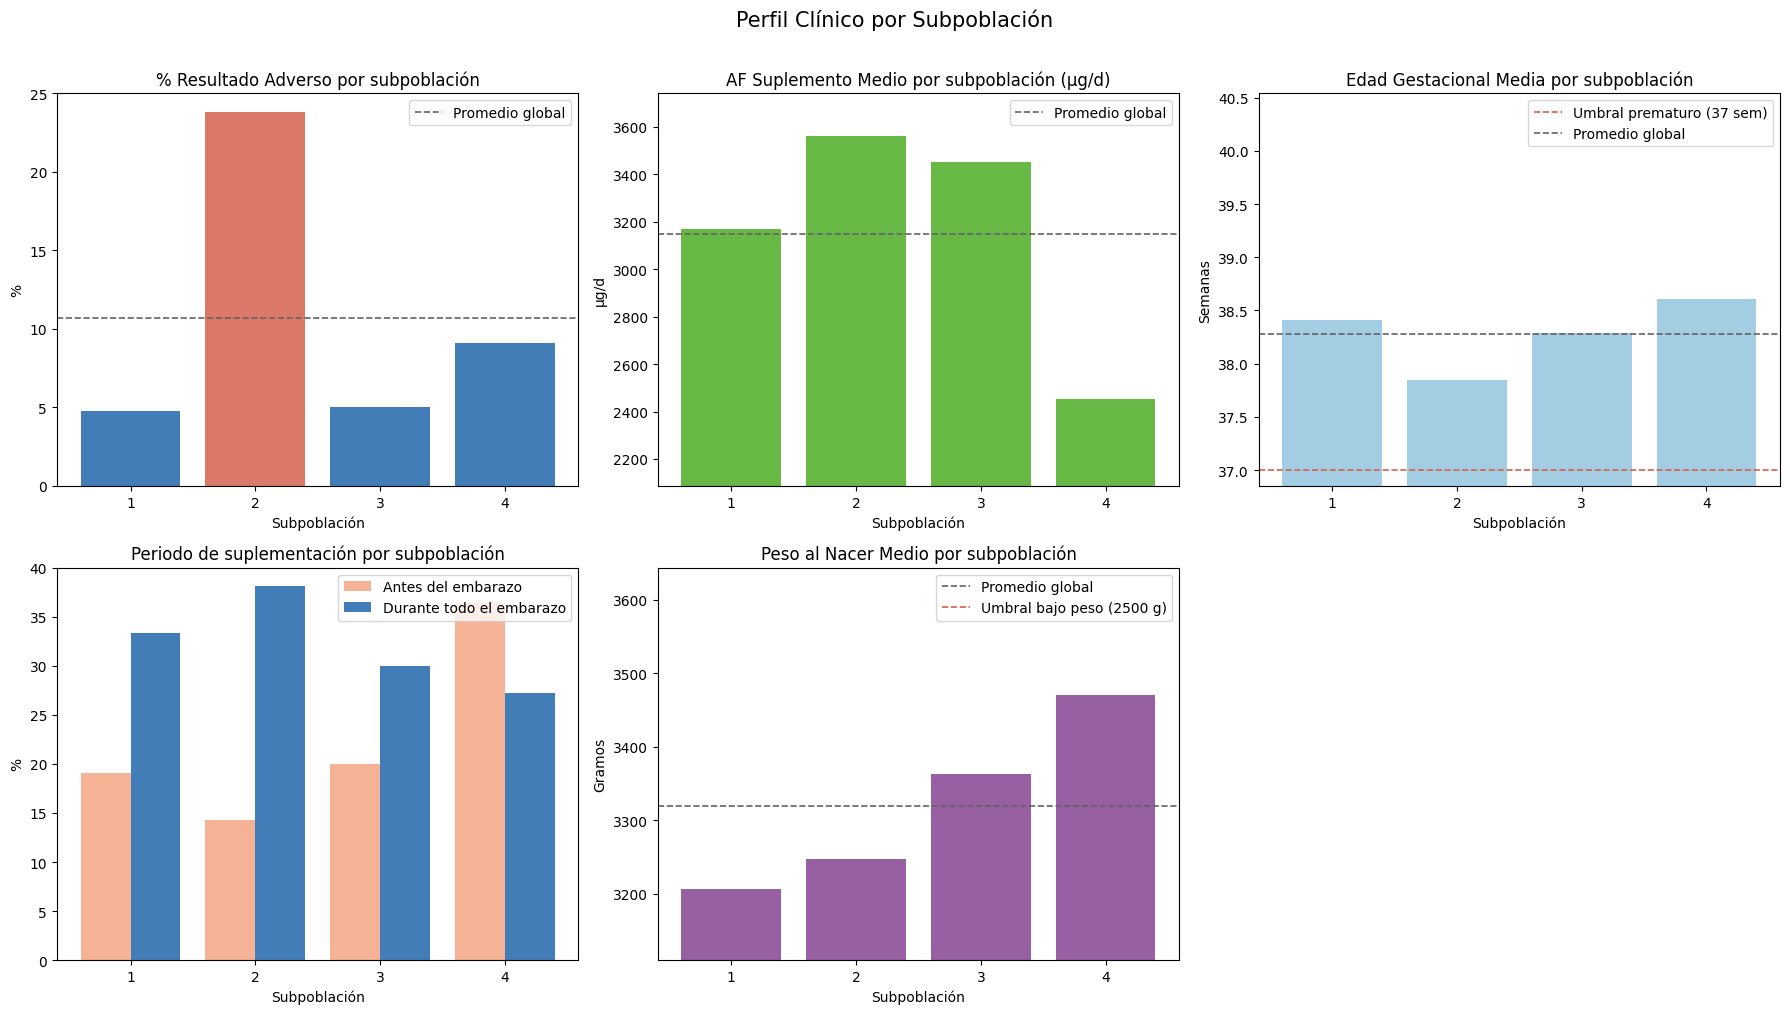

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. % Adverso por cluster
ax = axes[0, 0]
colores = [PALETTE['secondary'] if df_merge[df_merge['cluster_mapper']==cl]['resultado_adverso'].mean()*100 >
           df_merge['resultado_adverso'].mean()*100 else PALETTE['primary'] for cl in clusters]
ax.bar([str(int(c)+1) for c in clusters],
       [df_merge[df_merge['cluster_mapper']==cl]['resultado_adverso'].mean()*100 for cl in clusters],
       color=colores, edgecolor='none', alpha=0.85)  # PALETTE reemplaza 'red'/'steelblue'
ax.axhline(df_merge['resultado_adverso'].mean()*100, color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.set_title('% Resultado Adverso por subpoblación')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('%')
ax.legend()

# 2. AF medio por cluster
ax = axes[0, 1]
af_vals = [df_merge[df_merge['cluster_mapper']==cl]['uf_af'].mean() for cl in clusters]
af_min = min(af_vals)
ax.bar([str(int(c)+1) for c in clusters], af_vals,
       color=PALETTE['green'], edgecolor='none', alpha=0.85)  # PALETTE reemplaza 'mediumseagreen'
ax.axhline(df_merge['uf_af'].mean(), color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.set_ylim(bottom=af_min * 0.85)
ax.set_title('AF Suplemento Medio por subpoblación (μg/d)')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('μg/d')
ax.legend()

# 3. Edad gestacional media
ax = axes[0, 2]
eg_vals = [df_merge[df_merge['cluster_mapper']==cl]['eg_num'].mean() for cl in clusters]
eg_min = min(eg_vals)
ax.bar([str(int(c)+1) for c in clusters], eg_vals,
       color=PALETTE['light'], edgecolor='none', alpha=0.85)  # PALETTE reemplaza 'cornflowerblue'
ax.axhline(37, color=PALETTE['secondary'], linestyle='--', lw=1.2, label='Umbral prematuro (37 sem)')
ax.axhline(df_merge['eg_num'].mean(), color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.set_ylim(bottom=eg_min - 1)
ax.set_title('Edad Gestacional Media por subpoblación')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('Semanas')
ax.legend()

# 4. Timing: antes vs durante el embarazo
ax = axes[1, 0]
antes   = [df_merge[df_merge['cluster_mapper']==cl]['Antes del embarazo'].mean()*100 for cl in clusters]
durante = [df_merge[df_merge['cluster_mapper']==cl]['Durante todo el embarazo'].mean()*100 for cl in clusters]
x_pos = np.arange(len(clusters))
ax.bar(x_pos - 0.2, antes,   width=0.4, label='Antes del embarazo',
       color=PALETTE['accent'],  edgecolor='none', alpha=0.85)  # PALETTE reemplaza 'orange'
ax.bar(x_pos + 0.2, durante, width=0.4, label='Durante todo el embarazo',
       color=PALETTE['primary'], edgecolor='none', alpha=0.85)  # PALETTE reemplaza 'purple'
ax.set_xticks(x_pos)
ax.set_xticklabels([str(int(c)+1) for c in clusters])
ax.set_title('Periodo de suplementación por subpoblación')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('%')
ax.legend()

# 5. Peso al nacer medio
ax = axes[1, 1]
pn_vals = [df_merge[df_merge['cluster_mapper']==cl]['pnacer_num'].mean() for cl in clusters]
pn_min = min(pn_vals)
ax.bar([str(int(c)+1) for c in clusters], pn_vals,
       color=PALETTE['purple'], edgecolor='none', alpha=0.75)  # PALETTE reemplaza 'salmon'
ax.axhline(df_merge['pnacer_num'].mean(), color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.axhline(2500, color=PALETTE['secondary'], linestyle='--', lw=1.2, label='Umbral bajo peso (2500 g)')
ax.set_ylim(bottom=pn_min * 0.97)
ax.set_title('Peso al Nacer Medio por subpoblación')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('Gramos')
ax.legend()

# 6. Subplot vacío
axes[1, 2].set_visible(False)

plt.suptitle('Perfil Clínico por Subpoblación', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


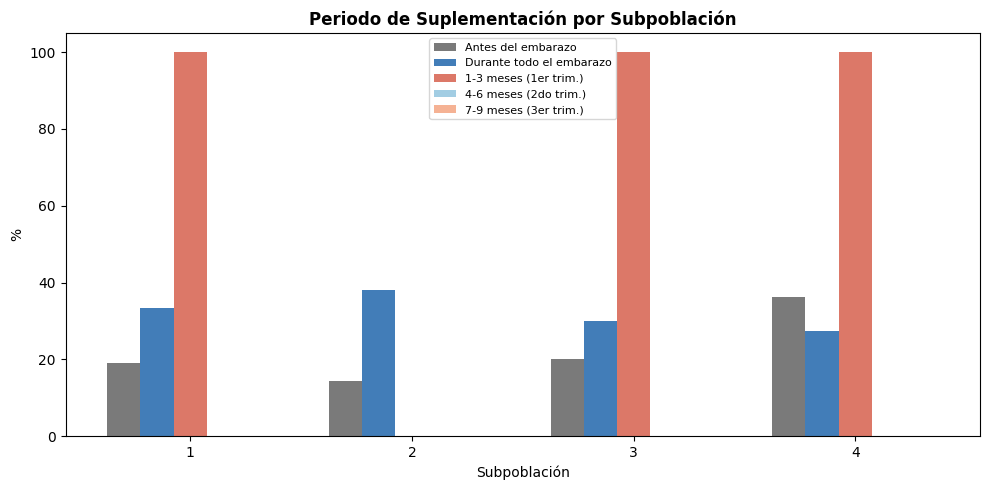

In [86]:
# Distribución por Trimestre de Inicio por Cluster
TIMING_COLS = ['Antes del embarazo', 'Durante todo el embarazo', '1-3 meses', '4-6 meses', '7-9 meses']

timing_faltantes = [c for c in TIMING_COLS if c not in df_merge.columns]
if timing_faltantes:
    df_merge = df_merge.merge(
        df[timing_faltantes].fillna(0),
        left_index=True, right_index=True, how='left'
    )

# Colores de PALETTE para los 5 periodos de timing
timing_vars = [
    ('Antes del embarazo',       PALETTE['gray'],      'Antes del embarazo'),
    ('Durante todo el embarazo', PALETTE['primary'],   'Durante todo el embarazo'),
    ('1-3 meses',                PALETTE['secondary'], '1-3 meses (1er trim.)'),
    ('4-6 meses',                PALETTE['light'],     '4-6 meses (2do trim.)'),
    ('7-9 meses',                PALETTE['accent'],    '7-9 meses (3er trim.)'),
]

x       = np.arange(len(clusters))
n_t     = len(timing_vars)
width   = 0.75 / n_t
offsets = np.linspace(-(n_t - 1) / 2, (n_t - 1) / 2, n_t) * width

fig, ax = plt.subplots(figsize=(10, 5))

for i, (col, color, label) in enumerate(timing_vars):
    vals = [
        df_merge[df_merge['cluster_mapper'] == cl][col].mean() * 100
        if col in df_merge.columns else 0.0
        for cl in clusters
    ]
    ax.bar(x + offsets[i], vals, width=width,
           label=label, color=color, edgecolor='none', alpha=0.85)  # sin borde duro

ax.set_xticks(x)
ax.set_xticklabels([str(int(c)+1) for c in clusters])
ax.set_title('Periodo de Suplementación por Subpoblación', fontweight='bold')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('%')
ax.legend(fontsize=8)  # frameon=False vía rcParams global
plt.tight_layout()
plt.show()


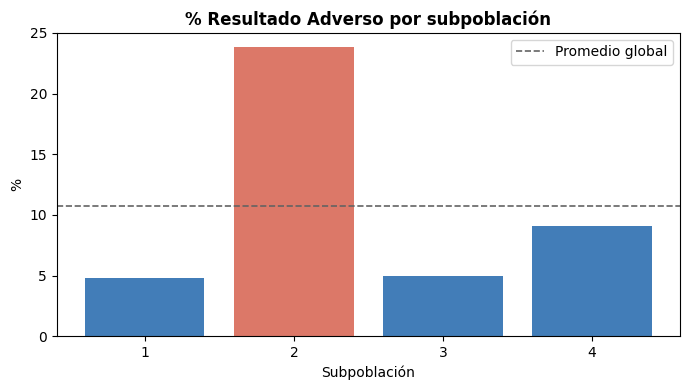

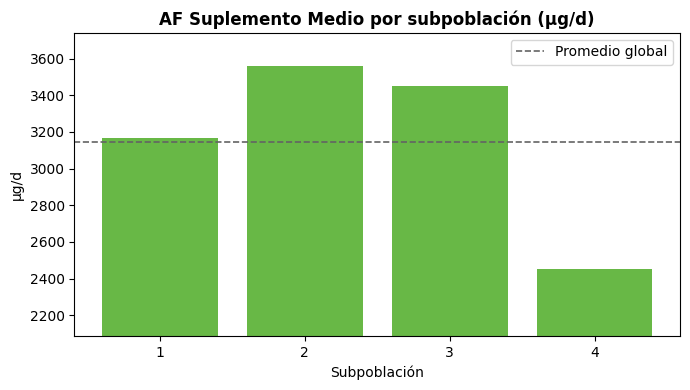

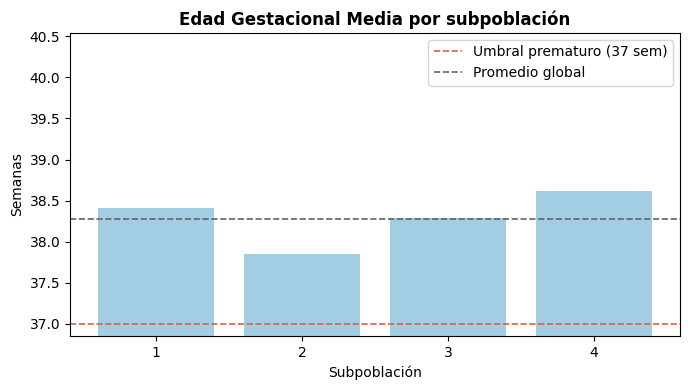

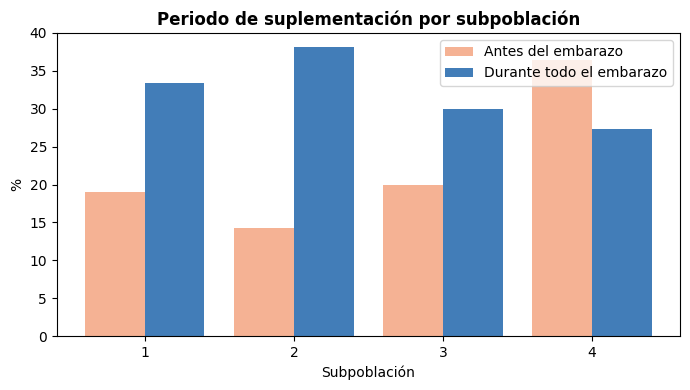

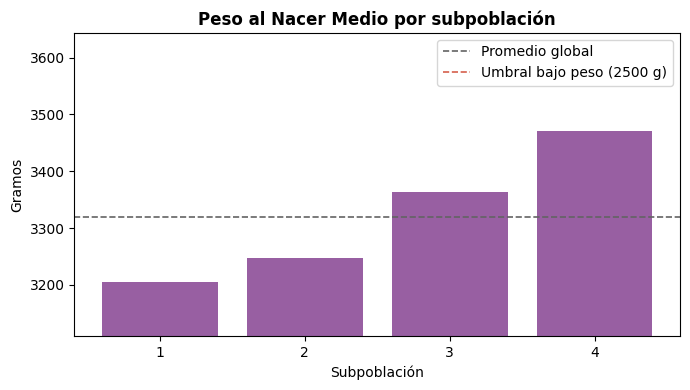

In [87]:
# 1. % Resultado Adverso por cluster
fig, ax = plt.subplots(figsize=(7, 4))
colores = [PALETTE['secondary'] if df_merge[df_merge['cluster_mapper']==cl]['resultado_adverso'].mean()*100 >
           df_merge['resultado_adverso'].mean()*100 else PALETTE['primary'] for cl in clusters]
ax.bar([str(int(c)+1) for c in clusters],
       [df_merge[df_merge['cluster_mapper']==cl]['resultado_adverso'].mean()*100 for cl in clusters],
       color=colores, edgecolor='none', alpha=0.85)
ax.axhline(df_merge['resultado_adverso'].mean()*100, color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.set_title('% Resultado Adverso por subpoblación', fontweight='bold')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
plt.show()

# 2. AF Suplemento Medio por cluster
fig, ax = plt.subplots(figsize=(7, 4))
af_vals = [df_merge[df_merge['cluster_mapper']==cl]['uf_af'].mean() for cl in clusters]
af_min = min(af_vals)
ax.bar([str(int(c)+1) for c in clusters], af_vals,
       color=PALETTE['green'], edgecolor='none', alpha=0.85)
ax.axhline(df_merge['uf_af'].mean(), color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.set_ylim(bottom=af_min * 0.85)
ax.set_title('AF Suplemento Medio por subpoblación (μg/d)', fontweight='bold')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('μg/d')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Edad Gestacional Media por cluster
fig, ax = plt.subplots(figsize=(7, 4))
eg_vals = [df_merge[df_merge['cluster_mapper']==cl]['eg_num'].mean() for cl in clusters]
eg_min = min(eg_vals)
ax.bar([str(int(c)+1) for c in clusters], eg_vals,
       color=PALETTE['light'], edgecolor='none', alpha=0.85)
ax.axhline(37, color=PALETTE['secondary'], linestyle='--', lw=1.2, label='Umbral prematuro (37 sem)')
ax.axhline(df_merge['eg_num'].mean(), color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.set_ylim(bottom=eg_min - 1)
ax.set_title('Edad Gestacional Media por subpoblación', fontweight='bold')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('Semanas')
ax.legend()
plt.tight_layout()
plt.show()

# 4. Periodo de suplementación por cluster
fig, ax = plt.subplots(figsize=(7, 4))
antes   = [df_merge[df_merge['cluster_mapper']==cl]['Antes del embarazo'].mean()*100 for cl in clusters]
durante = [df_merge[df_merge['cluster_mapper']==cl]['Durante todo el embarazo'].mean()*100 for cl in clusters]
x_pos = np.arange(len(clusters))
ax.bar(x_pos - 0.2, antes,   width=0.4, label='Antes del embarazo',
       color=PALETTE['accent'],  edgecolor='none', alpha=0.85)
ax.bar(x_pos + 0.2, durante, width=0.4, label='Durante todo el embarazo',
       color=PALETTE['primary'], edgecolor='none', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([str(int(c)+1) for c in clusters])
ax.set_title('Periodo de suplementación por subpoblación', fontweight='bold')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Peso al Nacer Medio por cluster
fig, ax = plt.subplots(figsize=(7, 4))
pn_vals = [df_merge[df_merge['cluster_mapper']==cl]['pnacer_num'].mean() for cl in clusters]
pn_min = min(pn_vals)
ax.bar([str(int(c)+1) for c in clusters], pn_vals,
       color=PALETTE['purple'], edgecolor='none', alpha=0.75)
ax.axhline(df_merge['pnacer_num'].mean(), color=PALETTE['gray'],
           linestyle='--', lw=1.2, label='Promedio global')
ax.axhline(2500, color=PALETTE['secondary'], linestyle='--', lw=1.2, label='Umbral bajo peso (2500 g)')
ax.set_ylim(bottom=pn_min * 0.97)
ax.set_title('Peso al Nacer Medio por subpoblación', fontweight='bold')
ax.set_xlabel('Subpoblación')
ax.set_ylabel('Gramos')
ax.legend()
plt.tight_layout()
plt.show()
